In [2]:
import argparse
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Dataset Path

In [14]:
TRAIN_PATH = "./dataset/train.csv"
TEST_PATH = "./dataset/test.csv"
SAMPLE_SUBMISSION_PATH = "./dataset/sample_submission.csv"

PLOT_PATH = "./plots"

TARGET = "Will_Buy_EV"
ID_COL = "id"
TARGET_LABELS = {0: "No (0)", 1: "Yes (1)"}

# Load data

In [12]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUBMISSION_PATH)

os.makedirs(PLOT_PATH, exist_ok=True)

print("=" * 70)
print("SHAPES")
print("=" * 70)
print(f"train: {train.shape}")
print(f"test : {test.shape}")
print(f"sample_submission: {sample_sub.shape}")

train[TARGET] = train[TARGET].map({"Yes": 1, "No": 0}).astype(int)

SHAPES
train: (668665, 15)
test : (286571, 14)
sample_submission: (286571, 2)


# Basic structure

## Train Info

In [5]:
print("\n" + "=" * 70)
print("TRAIN HEAD")
print("=" * 70)
print(train.head())

print("\n" + "=" * 70)
print("TRAIN INFO (dtypes, non-null counts)")
print("=" * 70)
train.info()


TRAIN HEAD
   id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  Charging_Stations_Near_Home  Charging_Stations_Near_Work  Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0   0   66            92887.0              23.4                     2                            3                            7                          1.0    Male  Suburban            Sedan   
1   1   38            30000.0               5.0                     1                            2                            2                          4.0    Male     Rural              SUV   
2   2   26            94389.0              36.8                     1                            8                           15                          5.0  Female     Urban            Sedan   
3   3   66            73580.0              23.7                     2                            6                            9                          3.0    Male  Suburban        Hatchback   
4   4   54   

## Test Info

In [6]:
print("\n" + "=" * 70)
print("TEST HEAD")
print("=" * 70)
print(test.head())

print("\n" + "=" * 70)
print("TEST INFO")
print("=" * 70)
test.info()


TEST HEAD
       id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  Charging_Stations_Near_Home  Charging_Stations_Near_Work  Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0  668665   61            67725.0              16.9                     2                            7                            4                          4.0    Male  Suburban            Sedan   
1  668666   42           152835.0              41.9                     2                            9                            9                          4.0    Male     Urban              SUV   
2  668667   68            86877.0              53.3                     1                           10                           11                          4.0  Female     Urban            Sedan   
3  668668   39            46794.0              34.1                     2                            4                            8                          4.0  Female  Suburban            Sed

# Missing values

In [7]:
print("\n" + "=" * 70)
print("MISSING VALUES - TRAIN")
print("=" * 70)
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print(missing_train if len(missing_train) else "No missing values in train.")

print("\n" + "=" * 70)
print("MISSING VALUES - TEST")
print("=" * 70)
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
print(missing_test if len(missing_test) else "No missing values in test.")


MISSING VALUES - TRAIN
No missing values in train.

MISSING VALUES - TEST
No missing values in test.


# Duplicates

In [8]:
print("\n" + "=" * 70)
print("DUPLICATES")
print("=" * 70)
print(f"Duplicate rows in train: {train.duplicated().shape[0] - train.drop_duplicates().shape[0]}")
print(f"Duplicate ids in train : {train[ID_COL].duplicated().sum()}")
print(f"Duplicate ids in test  : {test[ID_COL].duplicated().sum()}")


DUPLICATES
Duplicate rows in train: 0
Duplicate ids in train : 0
Duplicate ids in test  : 0


# Target distribution (class balance)


TARGET DISTRIBUTION
distribution count:
Will_Buy_EV
0    551886
1    116779

distribution percentage:
Will_Buy_EV
0    82.535 %
1    17.465 %
Name: proportion, dtype: str

Total samples: 668,665


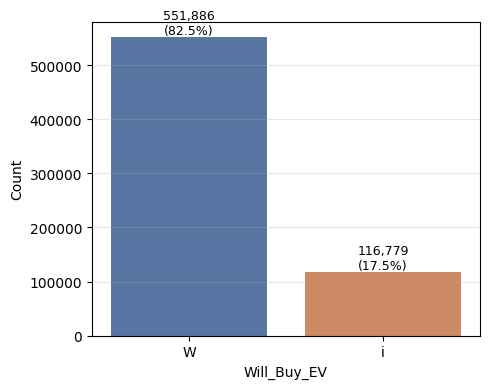

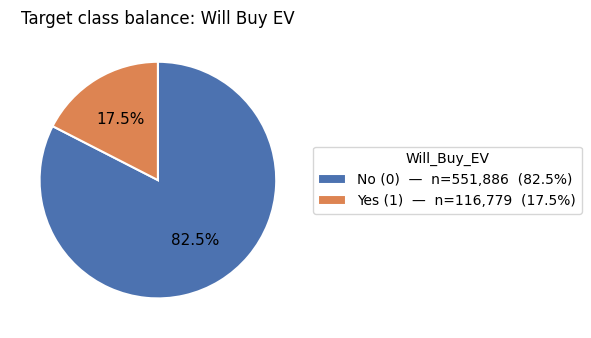

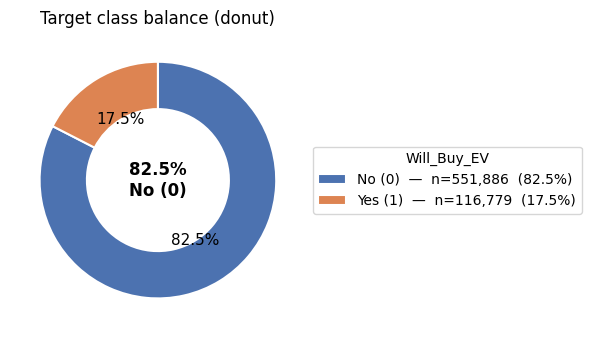

In [17]:
import seaborn as sns

#  Print summary
print("\n" + "=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)

counts = train[TARGET].value_counts().sort_index()
props  = train[TARGET].value_counts(normalize=True).sort_index()

print("distribution count:")
print(counts.to_string())
print("\ndistribution percentage:")
print((props * 100).round(3).astype(str) + " %")
print(f"\nTotal samples: {len(train):,}")

# COUNT PLOT (existing, cleaned up)
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=TARGET, data=train, ax=ax,
              hue=TARGET, palette={0: "#4C72B0", 1: "#DD8452"},
              legend=False)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([TARGET[k] for k in counts.index])
ax.set_xlabel(f"{TARGET}")
ax.set_ylabel("Count")

# annotate bars with count + %
for i, (k, v) in enumerate(counts.items()):
    ax.text(i, v, f"{v:,}\n({v/len(train)*100:.1f}%)",
            ha="center", va="bottom", fontsize=9)

# ax.set_title("Target class balance: Will Buy EV")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/target_balance.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# PIE CHART
fig, ax = plt.subplots(figsize=(6, 6))
labels = [TARGET_LABELS[k] for k in counts.index]
colors = ["#4C72B0", "#DD8452"]

wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
    textprops=dict(fontsize=11),
)

# legend with count + % so readers get both numbers
legend_labels = [
    f"{TARGET_LABELS[k]}  —  n={counts[k]:,}  ({counts[k]/len(train)*100:.1f}%)"
    for k in counts.index
]
ax.legend(wedges, legend_labels,
          title=f"{TARGET}", loc="center left",
          bbox_to_anchor=(1.0, 0.5), fontsize=10)

ax.set_title("Target class balance: Will Buy EV", fontsize=12)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/target_balance_pie.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# donut variant (nicer for a 2-class target)
fig, ax = plt.subplots(figsize=(6, 6))
wedges, _, autotexts = ax.pie(
    counts.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=1.5),
    textprops=dict(fontsize=11),
)
maj_pct = counts.iloc[0] / len(train) * 100
ax.text(0, 0, f"{maj_pct:.1f}%\n{TARGET_LABELS[counts.index[0]]}",
        ha="center", va="center", fontsize=12, fontweight="bold")

ax.legend(wedges, legend_labels, title=f"{TARGET}",
          loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=10)
ax.set_title("Target class balance (donut)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/target_balance_donut.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# Identify column types

In [19]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include=["object", "str", "category"]).columns.tolist()

for c in [ID_COL, TARGET]:
    if c in num_cols:
        num_cols.remove(c)
    if c in cat_cols:
        cat_cols.remove(c)

print("\n" + "=" * 70)
print("COLUMN TYPES")
print("=" * 70)
print(f"Numeric columns ({len(num_cols)}): {num_cols}")
print(f"Categorical/object columns ({len(cat_cols)}): {cat_cols}")


COLUMN TYPES
Numeric columns (7): ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']
Categorical/object columns (6): ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']


# Numeric feature summary

In [20]:
print("\n" + "=" * 70)
print("NUMERIC SUMMARY - TRAIN")
print("=" * 70)
print(train[num_cols].describe().T)


NUMERIC SUMMARY - TRAIN
                                count          mean           std      min      25%      50%       75%       max
Age                          668665.0     47.039171     12.875448     25.0     36.0     47.0      58.0      69.0
Annual_Income_USD            668665.0  84769.266989  28648.029042  30000.0  67376.0  84880.0  102753.0  188549.0
Daily_Commute_km             668665.0     32.158298     18.730474      5.0     17.2     33.6      47.4      98.7
Number_of_Cars_Owned         668665.0      1.712626      0.729275      1.0      1.0      2.0       2.0       4.0
Charging_Stations_Near_Home  668665.0      4.960408      3.926843      0.0      2.0      4.0       7.0      14.0
Charging_Stations_Near_Work  668665.0      7.176314      5.186627      0.0      3.0      6.0      10.0      19.0
Environmental_Concern_Level  668665.0      2.935477      1.429119      1.0      2.0      3.0       4.0       5.0


# Categorical feature summary (unique values / cardinality)

In [21]:
print("\n" + "=" * 70)
print("CATEGORICAL SUMMARY - TRAIN")
print("=" * 70)
for c in cat_cols:
    n_unique = train[c].nunique()
    print(f"\n{c}  (unique values: {n_unique})")
    print(train[c].value_counts(dropna=False))



CATEGORICAL SUMMARY - TRAIN

Gender  (unique values: 3)
Gender
Male      367954
Female    295427
Other       5284
Name: count, dtype: int64

City_Type  (unique values: 3)
City_Type
Urban       289305
Suburban    255377
Rural       123983
Name: count, dtype: int64

Current_Car_Type  (unique values: 4)
Current_Car_Type
Sedan        303459
SUV          246545
Hatchback     79438
Truck         39223
Name: count, dtype: int64

Home_Charging_Possible  (unique values: 2)
Home_Charging_Possible
Yes    462677
No     205988
Name: count, dtype: int64

Subsidy_Available  (unique values: 2)
Subsidy_Available
Yes    419909
No     248756
Name: count, dtype: int64

Range_Anxiety_Level  (unique values: 3)
Range_Anxiety_Level
Low       603972
Medium     62499
High        2194
Name: count, dtype: int64


# Check train/test consistency for categorical columns(values in test not seen in train can break some encoders)


TRAIN vs TEST CATEGORY CONSISTENCY
Gender: only_in_test=none, only_in_train=none
City_Type: only_in_test=none, only_in_train=none
Current_Car_Type: only_in_test=none, only_in_train=none
Home_Charging_Possible: only_in_test=none, only_in_train=none
Subsidy_Available: only_in_test=none, only_in_train=none
Range_Anxiety_Level: only_in_test=none, only_in_train=none


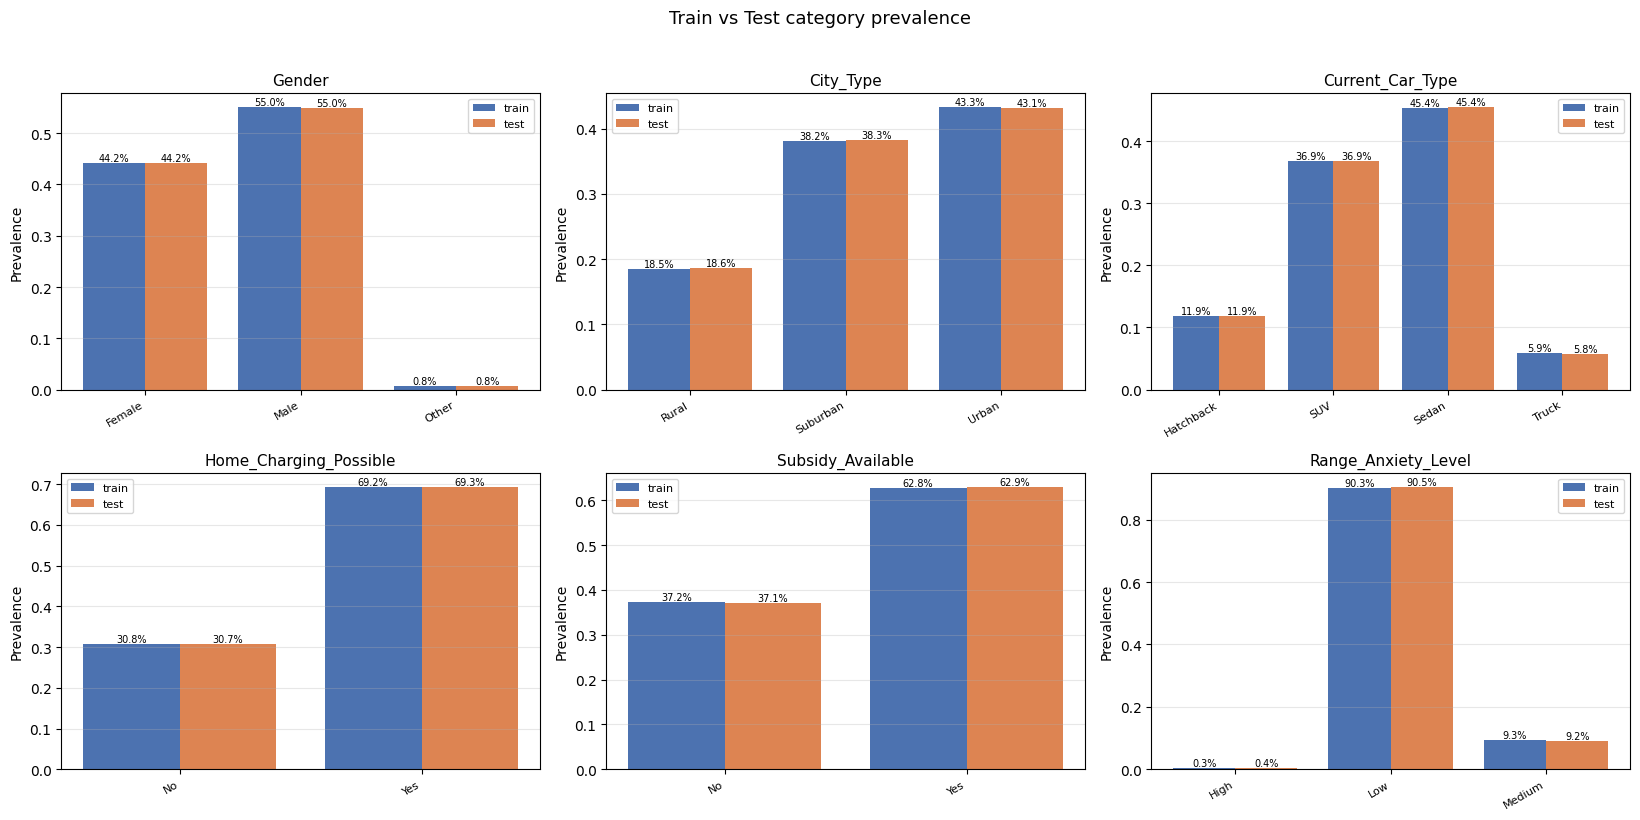

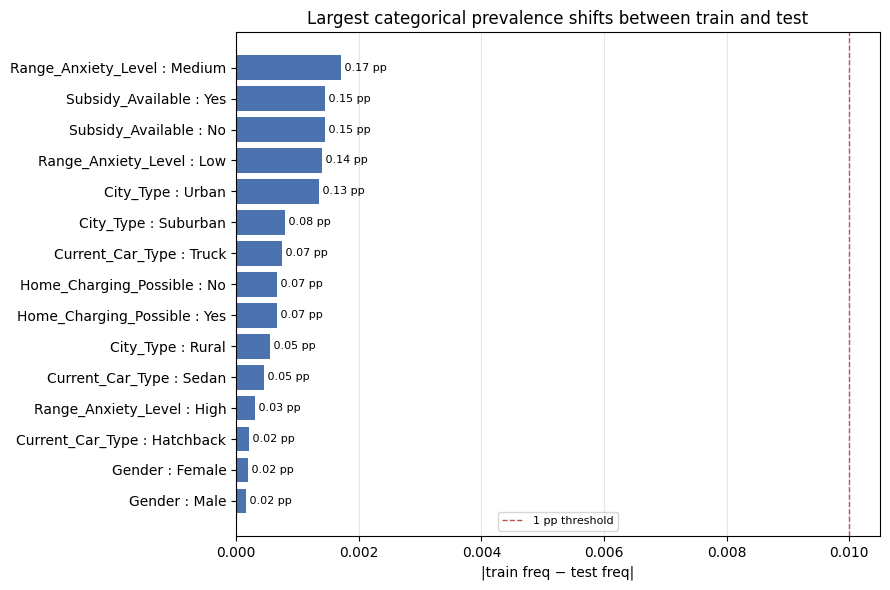

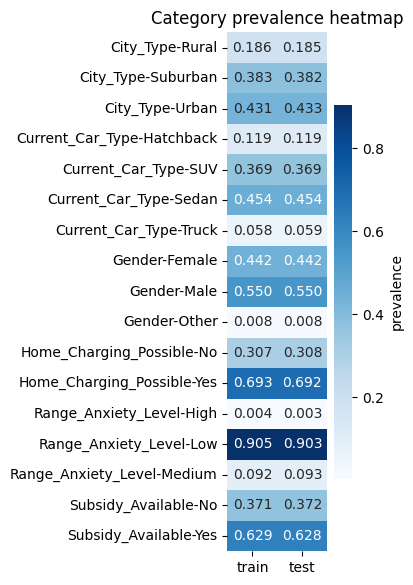


Top 10 category prevalence gaps (train vs test):
               feature  category  train_freq  test_freq  abs_diff
   Range_Anxiety_Level    Medium      0.0935     0.0918    0.0017
     Subsidy_Available       Yes      0.6280     0.6294    0.0015
     Subsidy_Available        No      0.3720     0.3706    0.0015
   Range_Anxiety_Level       Low      0.9033     0.9047    0.0014
             City_Type     Urban      0.4327     0.4313    0.0013
             City_Type  Suburban      0.3819     0.3827    0.0008
      Current_Car_Type     Truck      0.0587     0.0579    0.0007
Home_Charging_Possible        No      0.3081     0.3074    0.0007
Home_Charging_Possible       Yes      0.6919     0.6926    0.0007
             City_Type     Rural      0.1854     0.1860    0.0005
      Current_Car_Type     Sedan      0.4538     0.4543    0.0005
   Range_Anxiety_Level      High      0.0033     0.0036    0.0003
      Current_Car_Type Hatchback      0.1188     0.1190    0.0002
                Gender    

In [22]:
#  Consistency check + collect stats for plotting
print("\n" + "=" * 70)
print("TRAIN vs TEST CATEGORY CONSISTENCY")
print("=" * 70)

stats_rows = []
for c in cat_cols:
    train_vals = set(train[c].dropna().unique())
    test_vals  = set(test[c].dropna().unique())
    only_in_test  = test_vals - train_vals
    only_in_train = train_vals - test_vals
    print(f"{c}: only_in_test={only_in_test or 'none'}, "
          f"only_in_train={only_in_train or 'none'}")

    # per-category frequency in each split
    tr_freq = train[c].value_counts(normalize=True, dropna=False)
    te_freq = test[c].value_counts(normalize=True,  dropna=False)
    for cat in sorted(set(tr_freq.index) | set(te_freq.index), key=str):
        stats_rows.append({
            "feature":    c,
            "category":   str(cat),
            "train_freq": tr_freq.get(cat, 0.0),
            "test_freq":  te_freq.get(cat, 0.0),
        })

cons_df = pd.DataFrame(stats_rows)

# GROUPED BAR CHART
n_feats = len(cat_cols)
n_cols  = min(3, n_feats)
n_rows  = int(np.ceil(n_feats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, c in zip(axes, cat_cols):
    sub = cons_df[cons_df["feature"] == c].copy()
    x = np.arange(len(sub))
    w = 0.4

    ax.bar(x - w/2, sub["train_freq"], w, label="train", color="#4C72B0")
    ax.bar(x + w/2, sub["test_freq"],  w, label="test",  color="#DD8452")

    # label each bar with %
    for xi, v in zip(x - w/2, sub["train_freq"]):
        ax.text(xi, v, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=7)
    for xi, v in zip(x + w/2, sub["test_freq"]):
        ax.text(xi, v, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(sub["category"], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Prevalence")
    ax.set_title(c, fontsize=11)
    ax.grid(alpha=0.3, axis="y")
    ax.legend(fontsize=8)

# hide unused subplots
for ax in axes[n_feats:]:
    ax.axis("off")

plt.suptitle("Train vs Test category prevalence", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/cat_consistency_bars.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# ABSOLUTE DIFFERENCE BAR — sorted by max |Δfrequency|
cons_df["abs_diff"] = (cons_df["train_freq"] - cons_df["test_freq"]).abs()
worst = cons_df.sort_values("abs_diff", ascending=False).head(15).copy()
worst["label"] = worst["feature"] + " : " + worst["category"]

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#C44E52" if d > 0.01 else "#4C72B0" for d in worst["abs_diff"]]
ax.barh(worst["label"], worst["abs_diff"], color=colors)
ax.invert_yaxis()

for i, v in enumerate(worst["abs_diff"]):
    ax.text(v, i, f" {v*100:.2f} pp", va="center", fontsize=8)

ax.axvline(0.01, color="#C44E52", ls="--", lw=1, label="1 pp threshold")
ax.set_xlabel("|train freq − test freq|")
ax.set_title("Largest categorical prevalence shifts between train and test")
ax.grid(alpha=0.3, axis="x")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/cat_consistency_diff.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# HEATMAP — all categories × {train, test}
pivot = cons_df.pivot_table(
    index=["feature", "category"], values=["train_freq", "test_freq"]
)
pivot.columns = ["train", "test"]

fig, ax = plt.subplots(figsize=(4, max(4, 0.35 * len(pivot))))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues",
            cbar_kws={"label": "prevalence"}, ax=ax)
ax.set_title("Category prevalence heatmap")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/cat_consistency_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# SUMMARY TABLE — worst offenders
print("\nTop 10 category prevalence gaps (train vs test):")
print(worst[["feature", "category", "train_freq", "test_freq", "abs_diff"]]
      .round(4).to_string(index=False))

cons_df.to_csv(f"{PLOT_PATH}/cat_consistency.csv", index=False)

# Distribution plots for numeric features (by target)

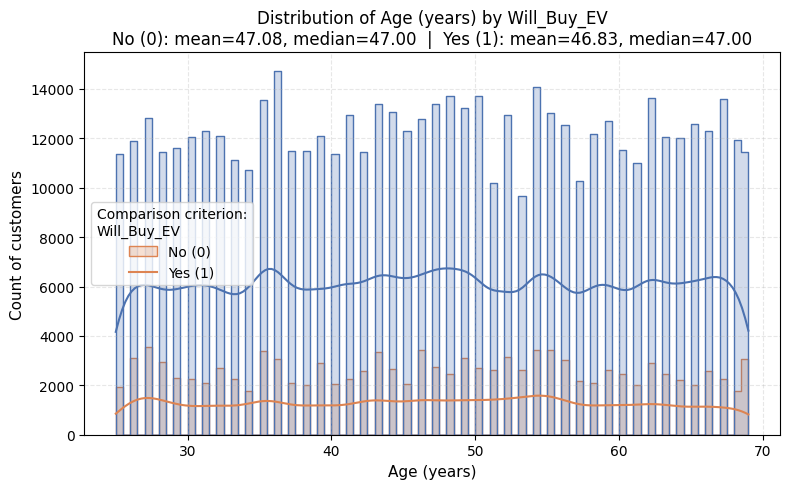

Saved: ./plots\hist_Age_by_Will_Buy_EV.png


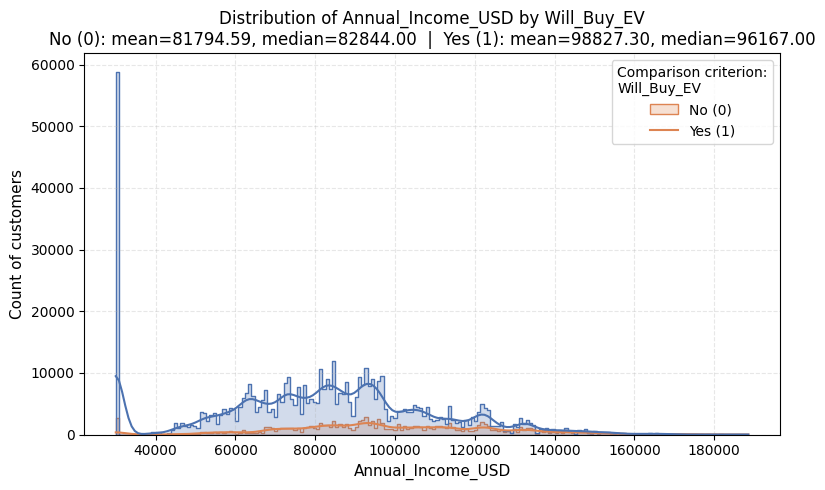

Saved: ./plots\hist_Annual_Income_USD_by_Will_Buy_EV.png


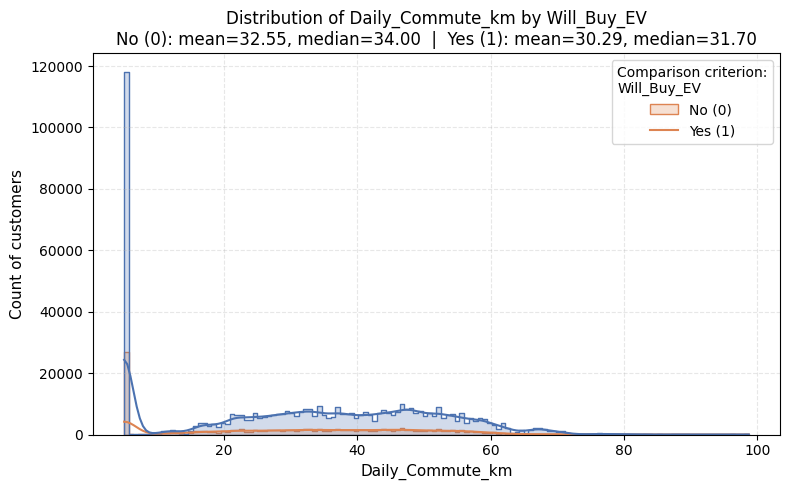

Saved: ./plots\hist_Daily_Commute_km_by_Will_Buy_EV.png


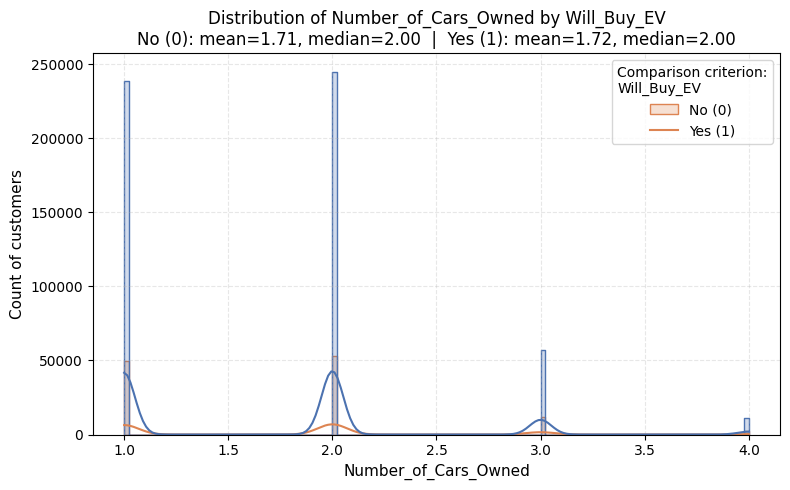

Saved: ./plots\hist_Number_of_Cars_Owned_by_Will_Buy_EV.png


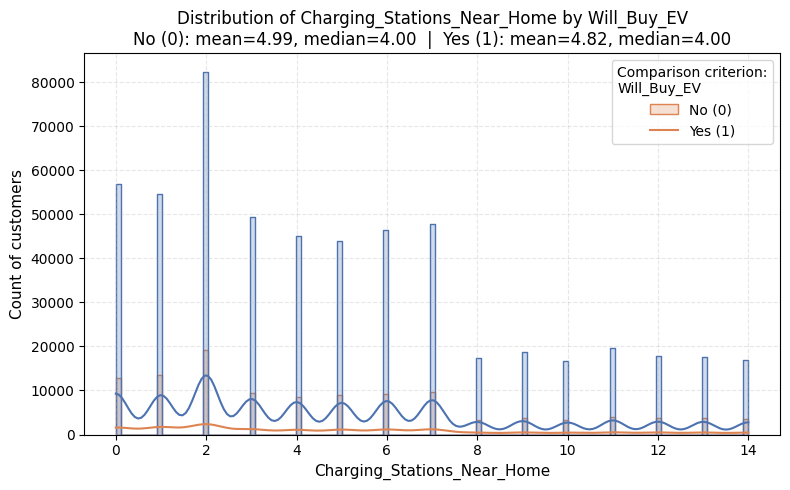

Saved: ./plots\hist_Charging_Stations_Near_Home_by_Will_Buy_EV.png


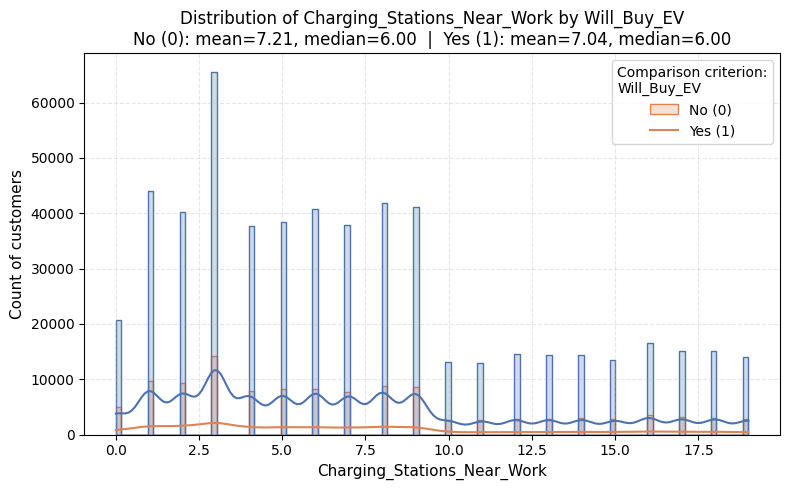

Saved: ./plots\hist_Charging_Stations_Near_Work_by_Will_Buy_EV.png


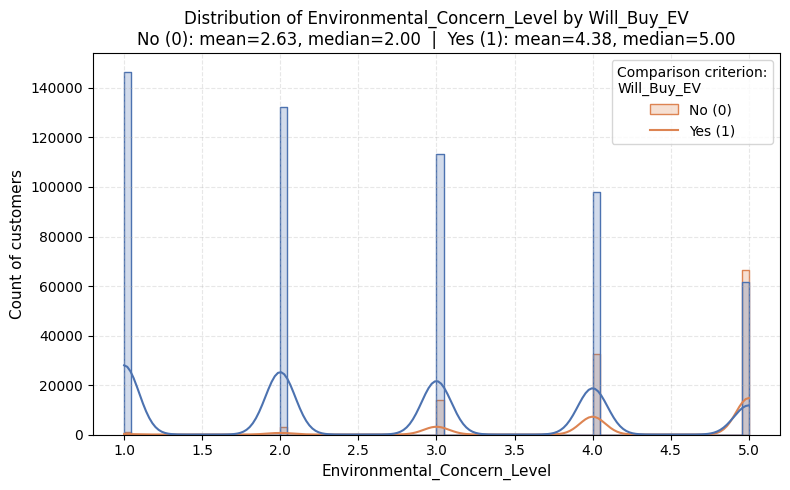

Saved: ./plots\hist_Environmental_Concern_Level_by_Will_Buy_EV.png


In [23]:
UNITS = {
    "Age": "years",
    "Annual_Income": "USD",
    "Daily_Commute_Distance": "km",
    "Vehicle_Price": "USD",
    "Fuel_Cost_Per_Year": "USD",
    "Charging_Station_Density": "stations / 100 km²",
}

# One plot per numeric feature
for c in num_cols:
    unit = UNITS.get(c, "")
    unit_str = f" ({unit})" if unit else ""

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(
        data=train,
        x=c,
        hue=TARGET,
        kde=True,
        element="step",
        stat="count",              
        common_norm=False,         
        palette={0: "#4C72B0", 1: "#DD8452"},
        ax=ax,
    )

    # axis labels with units 
    ax.set_xlabel(f"{c}{unit_str}", fontsize=11)
    ax.set_ylabel("Count of customers", fontsize=11)

    # title with per-class summary stats 
    g = train.groupby(TARGET)[c]
    title_stats = "  |  ".join(
        f"{TARGET_LABELS[k]}: mean={g.mean()[k]:.2f}, median={g.median()[k]:.2f}"
        for k in sorted(g.mean().index)
    )
    ax.set_title(
        f"Distribution of {c}{unit_str} by {TARGET}\n{title_stats}",
        fontsize=12,
    )

    # legend: name the comparison criterion explicitly 
    leg = ax.legend(
        title=f"Comparison criterion:\n{TARGET}",
        labels=[TARGET_LABELS[k] for k in sorted(TARGET_LABELS)],
        loc="best",
        frameon=True,
    )
    leg.get_title().set_fontsize(10)

    ax.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()

    # save with a descriptive file name 
    safe_name = c.replace(" ", "_").replace("/", "_")
    out_file = os.path.join(PLOT_PATH, f"hist_{safe_name}_by_{TARGET}.png")
    plt.savefig(out_file, dpi=130, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved: {out_file}")

# Categorical vs target (buy rate per category)

In [24]:
print("\n" + "=" * 70)
print("BUY RATE BY CATEGORY")
print("=" * 70)
for c in cat_cols:
    rate = train.groupby(c)[TARGET].mean().sort_values(ascending=False)
    print(f"\n{c}:")
    print(rate)


BUY RATE BY CATEGORY

Gender:
Gender
Female    0.177641
Other     0.173732
Male      0.172253
Name: Will_Buy_EV, dtype: float64

City_Type:
City_Type
Rural       0.193389
Suburban    0.180936
Urban       0.161058
Name: Will_Buy_EV, dtype: float64

Current_Car_Type:
Current_Car_Type
SUV          0.180953
Hatchback    0.174299
Sedan        0.171967
Truck        0.156413
Name: Will_Buy_EV, dtype: float64

Home_Charging_Possible:
Home_Charging_Possible
Yes    0.195819
No     0.127085
Name: Will_Buy_EV, dtype: float64

Subsidy_Available:
Subsidy_Available
Yes    0.274695
No     0.005757
Name: Will_Buy_EV, dtype: float64

Range_Anxiety_Level:
Range_Anxiety_Level
Low       0.189027
Medium    0.041745
High      0.001367
Name: Will_Buy_EV, dtype: float64


# Correlation matrix (numeric features + target)


CORRELATION WITH TARGET (numeric features)
Environmental_Concern_Level    0.464079
Annual_Income_USD              0.225729
Daily_Commute_km              -0.045866
Charging_Stations_Near_Home   -0.016353
Charging_Stations_Near_Work   -0.012229
Age                           -0.007450
Number_of_Cars_Owned           0.003896
Name: Will_Buy_EV, dtype: float64


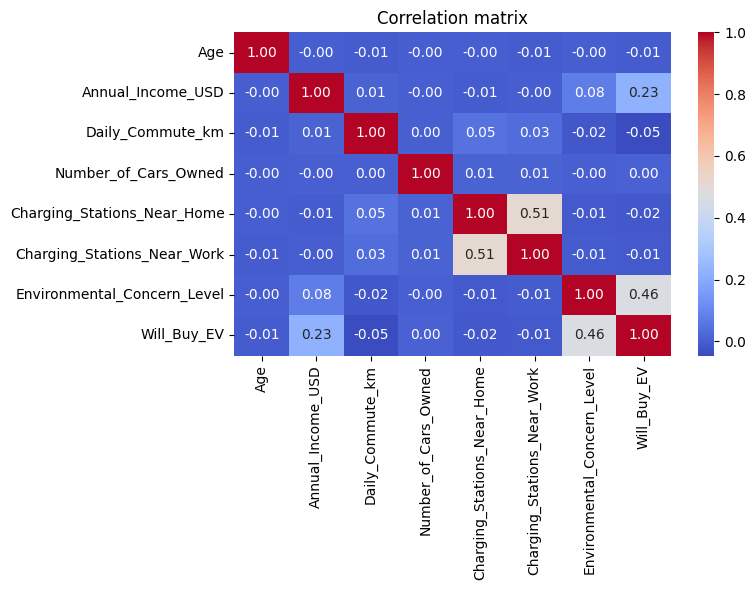

In [25]:
print("\n" + "=" * 70)
print("CORRELATION WITH TARGET (numeric features)")
print("=" * 70)
corr_with_target = train[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(corr_with_target)

plt.figure(figsize=(8, 6))
sns.heatmap(train[num_cols + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/correlation_matrix.png")
plt.show()
plt.close()


# Outlier check (simple IQR based)

In [21]:
print("\n" + "=" * 70)
print("OUTLIER CHECK (IQR method)")
print("=" * 70)
for c in num_cols:
    q1, q3 = train[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((train[c] < lower) | (train[c] > upper)).sum()
    print(f"{c}: {n_outliers} potential outliers "
        f"(bounds: [{lower:.2f}, {upper:.2f}])")


OUTLIER CHECK (IQR method)
Age: 0 potential outliers (bounds: [3.00, 91.00])
Annual_Income_USD: 3678 potential outliers (bounds: [14310.50, 155818.50])
Daily_Commute_km: 41 potential outliers (bounds: [-28.10, 92.70])
Number_of_Cars_Owned: 13489 potential outliers (bounds: [-0.50, 3.50])
Charging_Stations_Near_Home: 0 potential outliers (bounds: [-5.50, 14.50])
Charging_Stations_Near_Work: 0 potential outliers (bounds: [-7.50, 20.50])
Environmental_Concern_Level: 0 potential outliers (bounds: [-1.00, 7.00])


# FEATURE SUMMARY TABLE

In [22]:
rows = []
for c in num_cols:
    rows.append({
        "feature": c,
        "type": "numeric",
        "n_unique": train[c].nunique(),
        "min": train[c].min(),
        "max": train[c].max(),
        "mean": train[c].mean(),
        "std": train[c].std(),
        "skew": train[c].skew(),
        "kurtosis": train[c].kurtosis(),
        "missing": train[c].isna().sum(),
    })
for c in cat_cols:
    rows.append({
        "feature": c,
        "type": "categorical",
        "n_unique": train[c].nunique(),
        "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan,
        "skew": np.nan, "kurtosis": np.nan,
        "missing": train[c].isna().sum(),
    })

summary = pd.DataFrame(rows).sort_values("feature").reset_index(drop=True)
print(summary.to_string(index=False))
summary.to_csv(f"{PLOT_PATH}/feature_summary.csv", index=False)

                    feature        type  n_unique     min      max         mean          std      skew  kurtosis  missing
                        Age     numeric        45    25.0     69.0    47.039171    12.875448 -0.003786 -1.174029        0
          Annual_Income_USD     numeric     13214 30000.0 188549.0 84769.266989 28648.029042 -0.013086 -0.149234        0
Charging_Stations_Near_Home     numeric        15     0.0     14.0     4.960408     3.926843  0.698730 -0.482457        0
Charging_Stations_Near_Work     numeric        20     0.0     19.0     7.176314     5.186627  0.700188 -0.489245        0
                  City_Type categorical         3     NaN      NaN          NaN          NaN       NaN       NaN        0
           Current_Car_Type categorical         4     NaN      NaN          NaN          NaN       NaN       NaN        0
           Daily_Commute_km     numeric       805     5.0     98.7    32.158298    18.730474 -0.084589 -1.060918        0
Environmental_Concern_Le

# TARGET RATE BY BINNED NUMERIC FEATURE

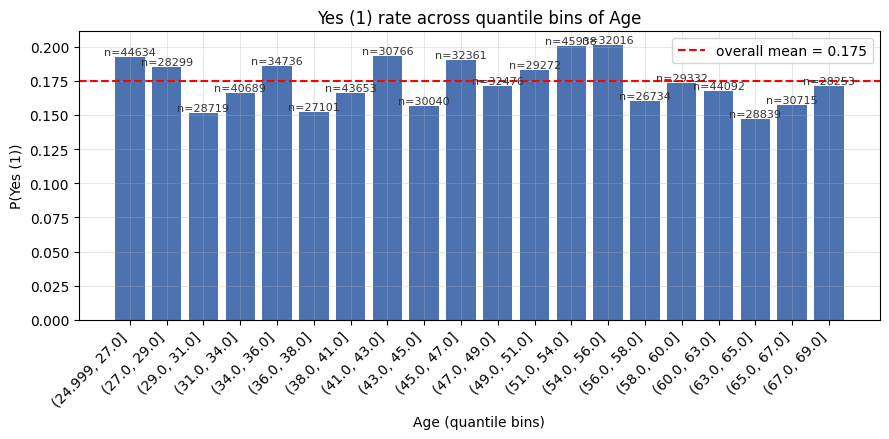


Age:
                  rate  count
bin                          
(24.999, 27.0]  0.1921  44634
(27.0, 29.0]    0.1853  28299
(29.0, 31.0]    0.1515  28719
(31.0, 34.0]    0.1663  40689
(34.0, 36.0]    0.1859  34736
(36.0, 38.0]    0.1518  27101
(38.0, 41.0]    0.1659  43653
(41.0, 43.0]    0.1930  30766
(43.0, 45.0]    0.1562  30040
(45.0, 47.0]    0.1902  32361
(47.0, 49.0]    0.1709  32476
(49.0, 51.0]    0.1830  29272
(51.0, 54.0]    0.2006  45938
(54.0, 56.0]    0.2011  32016
(56.0, 58.0]    0.1601  26734
(58.0, 60.0]    0.1737  29332
(60.0, 63.0]    0.1677  44092
(63.0, 65.0]    0.1471  28839
(65.0, 67.0]    0.1573  30715
(67.0, 69.0]    0.1713  28253


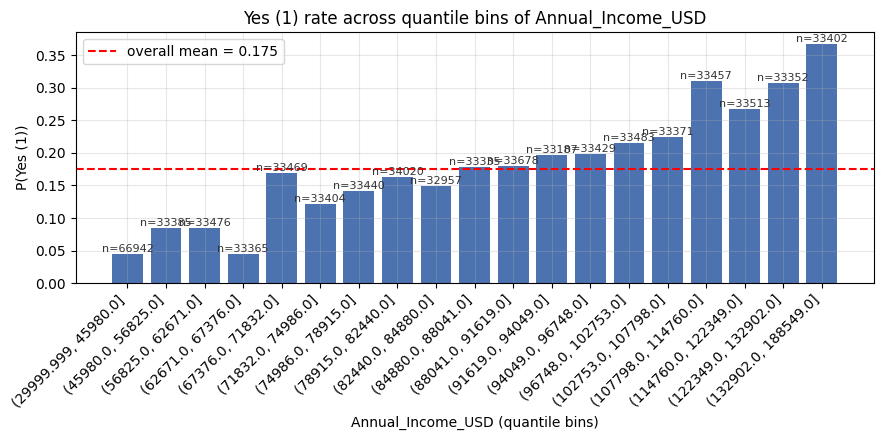


Annual_Income_USD:
                        rate  count
bin                                
(29999.999, 45980.0]  0.0445  66942
(45980.0, 56825.0]    0.0851  33385
(56825.0, 62671.0]    0.0841  33476
(62671.0, 67376.0]    0.0445  33365
(67376.0, 71832.0]    0.1685  33469
(71832.0, 74986.0]    0.1213  33404
(74986.0, 78915.0]    0.1420  33440
(78915.0, 82440.0]    0.1623  34020
(82440.0, 84880.0]    0.1496  32957
(84880.0, 88041.0]    0.1791  33335
(88041.0, 91619.0]    0.1804  33678
(91619.0, 94049.0]    0.1968  33187
(94049.0, 96748.0]    0.1985  33429
(96748.0, 102753.0]   0.2149  33483
(102753.0, 107798.0]  0.2243  33371
(107798.0, 114760.0]  0.3100  33457
(114760.0, 122349.0]  0.2681  33513
(122349.0, 132902.0]  0.3077  33352
(132902.0, 188549.0]  0.3669  33402


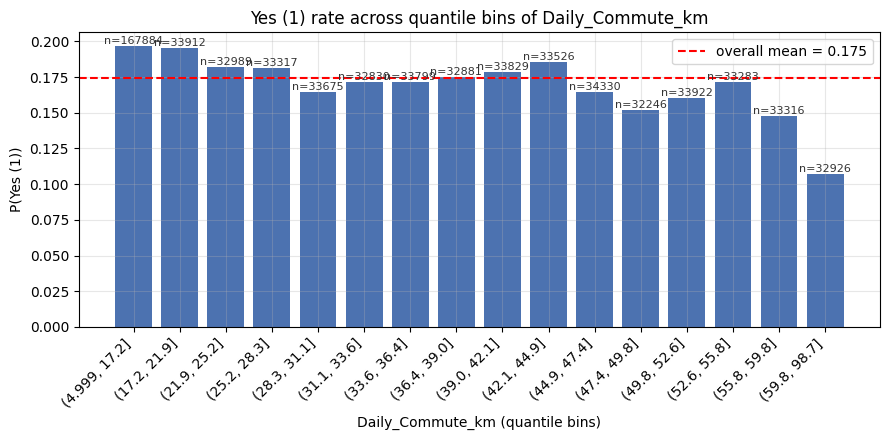


Daily_Commute_km:
                 rate   count
bin                          
(4.999, 17.2]  0.1966  167884
(17.2, 21.9]   0.1951   33912
(21.9, 25.2]   0.1820   32989
(25.2, 28.3]   0.1812   33317
(28.3, 31.1]   0.1646   33675
(31.1, 33.6]   0.1716   32830
(33.6, 36.4]   0.1719   33799
(36.4, 39.0]   0.1750   32881
(39.0, 42.1]   0.1785   33829
(42.1, 44.9]   0.1856   33526
(44.9, 47.4]   0.1643   34330
(47.4, 49.8]   0.1518   32246
(49.8, 52.6]   0.1603   33922
(52.6, 55.8]   0.1713   33283
(55.8, 59.8]   0.1477   33316
(59.8, 98.7]   0.1070   32926


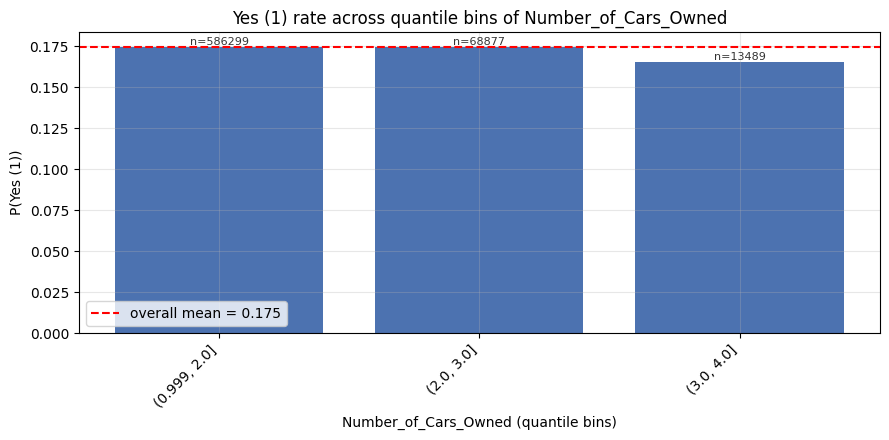


Number_of_Cars_Owned:
                rate   count
bin                         
(0.999, 2.0]  0.1748  586299
(2.0, 3.0]    0.1748   68877
(3.0, 4.0]    0.1657   13489


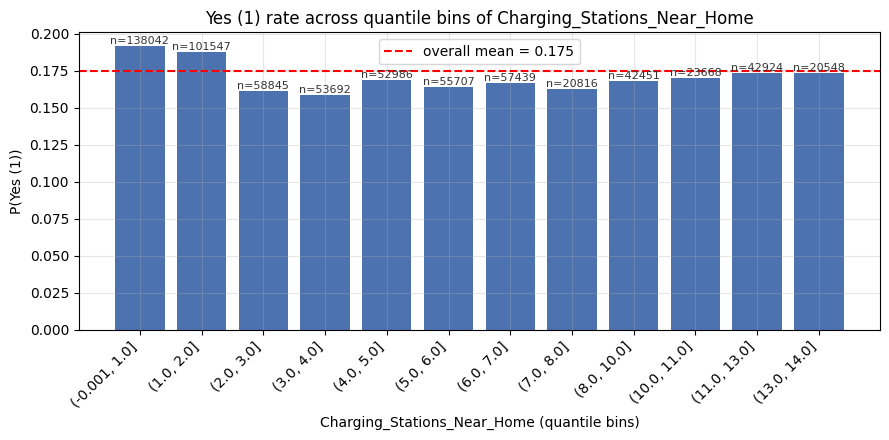


Charging_Stations_Near_Home:
                 rate   count
bin                          
(-0.001, 1.0]  0.1915  138042
(1.0, 2.0]     0.1880  101547
(2.0, 3.0]     0.1615   58845
(3.0, 4.0]     0.1585   53692
(4.0, 5.0]     0.1685   52986
(5.0, 6.0]     0.1643   55707
(6.0, 7.0]     0.1669   57439
(7.0, 8.0]     0.1627   20816
(8.0, 10.0]    0.1681   42451
(10.0, 11.0]   0.1701   23668
(11.0, 13.0]   0.1738   42924
(13.0, 14.0]   0.1734   20548


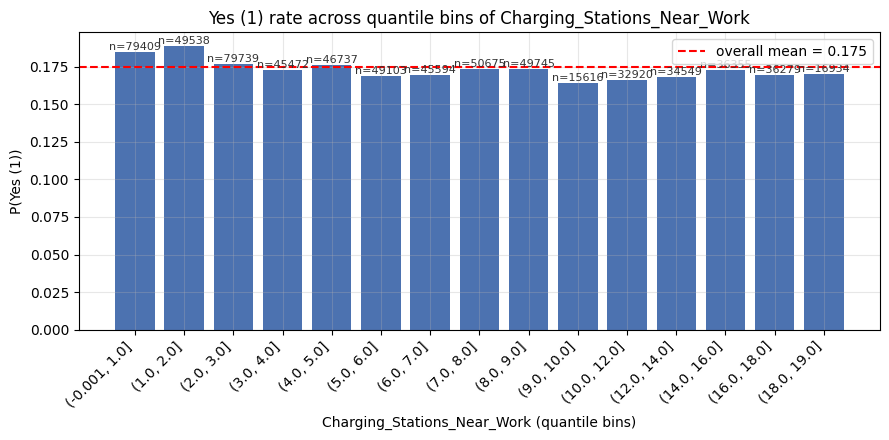


Charging_Stations_Near_Work:
                 rate  count
bin                         
(-0.001, 1.0]  0.1848  79409
(1.0, 2.0]     0.1884  49538
(2.0, 3.0]     0.1770  79739
(3.0, 4.0]     0.1726  45472
(4.0, 5.0]     0.1761  46737
(5.0, 6.0]     0.1688  49103
(6.0, 7.0]     0.1697  45594
(7.0, 8.0]     0.1736  50675
(8.0, 9.0]     0.1736  49745
(9.0, 10.0]    0.1639  15616
(10.0, 12.0]   0.1659  32920
(12.0, 14.0]   0.1678  34549
(14.0, 16.0]   0.1727  36355
(16.0, 18.0]   0.1693  36279
(18.0, 19.0]   0.1698  16934


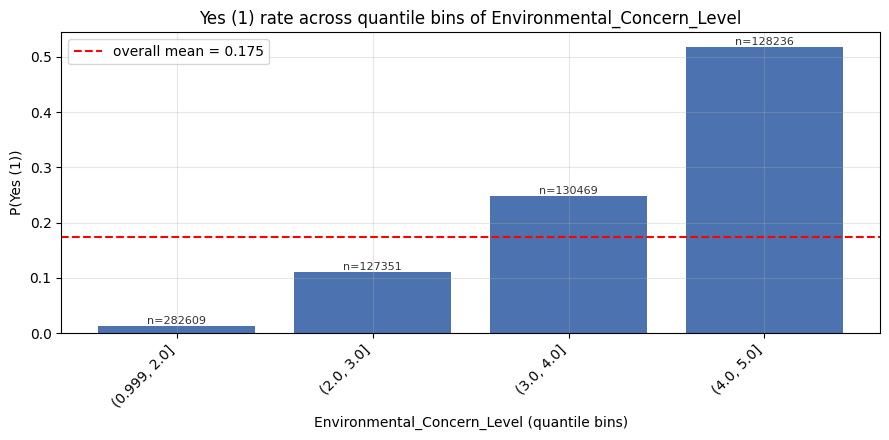


Environmental_Concern_Level:
                rate   count
bin                         
(0.999, 2.0]  0.0132  282609
(2.0, 3.0]    0.1109  127351
(3.0, 4.0]    0.2488  130469
(4.0, 5.0]    0.5183  128236

Trend summary (first bin → last bin):
                         Age  0.192 → 0.171  ↓
           Annual_Income_USD  0.044 → 0.367  ↑
            Daily_Commute_km  0.197 → 0.107  ↓
        Number_of_Cars_Owned  0.175 → 0.166  ↓
 Charging_Stations_Near_Home  0.191 → 0.173  ↓
 Charging_Stations_Near_Work  0.185 → 0.170  ↓
 Environmental_Concern_Level  0.013 → 0.518  ↑


In [27]:
N_BINS = 20
bin_rate_tables = {}
overall = train[TARGET].mean()

for c in num_cols:
    tmp = train[[c, TARGET]].dropna(subset=[c]).copy()
    try:
        tmp["bin"] = pd.qcut(tmp[c], q=N_BINS, duplicates="drop")
        binned_by = "quantile"
    except (ValueError, TypeError):
        tmp["bin"] = pd.cut(tmp[c], bins=N_BINS)
        binned_by = "equal-width"

    g = (
        tmp.groupby("bin", observed=True)[TARGET]
        .agg(rate="mean", count="count")
    )
    bin_rate_tables[c] = g

    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(g))
    bars = ax.bar(x, g["rate"], color="#4C72B0")
    ax.axhline(overall, color="red", ls="--",
               label=f"overall mean = {overall:.3f}")

    for b, cnt in zip(bars, g["count"]):
        ax.annotate(f"n={cnt}", (b.get_x() + b.get_width()/2, b.get_height()),
                    ha="center", va="bottom", fontsize=8, color="#333")

    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in g.index], rotation=45, ha="right")
    ax.set_xlabel(f"{c} ({binned_by} bins)")
    ax.set_ylabel(f"P({TARGET_LABELS[1]})")
    ax.set_title(f"{TARGET_LABELS[1]} rate across {binned_by} bins of {c}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/rate_bins_{c}.png", dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"\n{c}:")
    print(g.round(4).to_string())

# trend summary
print("\nTrend summary (first bin → last bin):")
for c, g in bin_rate_tables.items():
    r = g["rate"].values
    arrow = "↑" if r[-1] > r[0] else ("↓" if r[-1] < r[0] else "≈")
    print(f"{c:>28s}  {r[0]:.3f} → {r[-1]:.3f}  {arrow}")

# CATEGORICAL BUY RATE WITH 95% CI

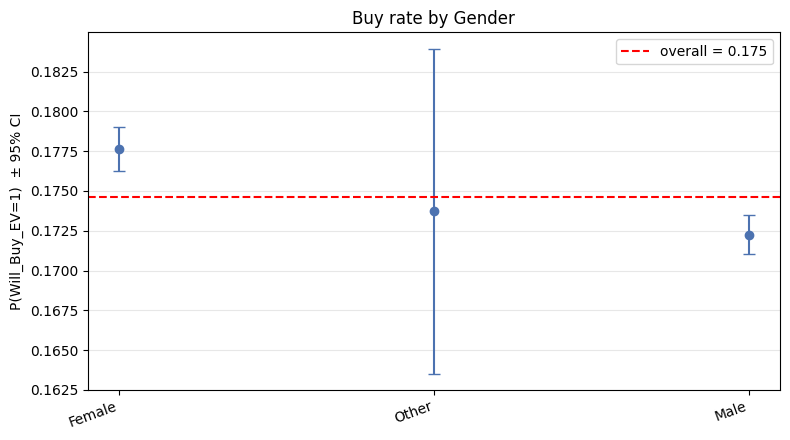


Gender:
          mean   count      se   ci_lo   ci_hi
Gender                                        
Female  0.1776  295427  0.0007  0.1763  0.1790
Other   0.1737    5284  0.0052  0.1635  0.1839
Male    0.1723  367954  0.0006  0.1710  0.1735


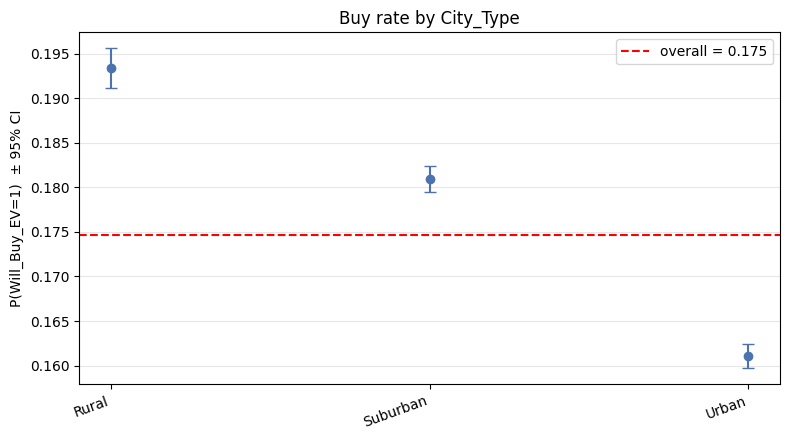


City_Type:
             mean   count      se   ci_lo   ci_hi
City_Type                                        
Rural      0.1934  123983  0.0011  0.1912  0.1956
Suburban   0.1809  255377  0.0008  0.1794  0.1824
Urban      0.1611  289305  0.0007  0.1597  0.1624


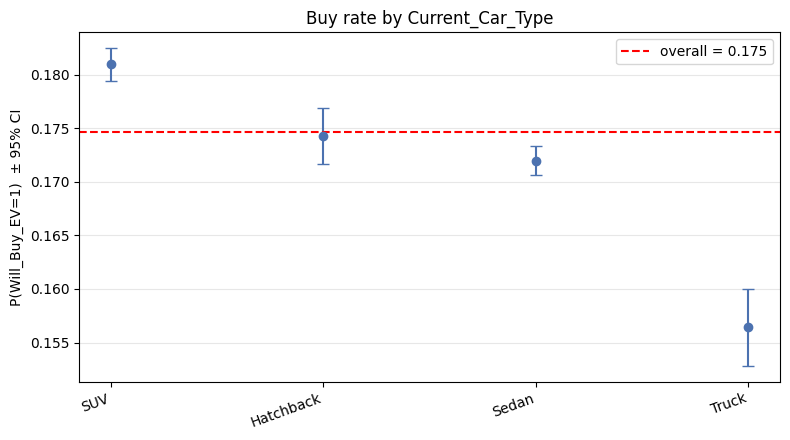


Current_Car_Type:
                    mean   count      se   ci_lo   ci_hi
Current_Car_Type                                        
SUV               0.1810  246545  0.0008  0.1794  0.1825
Hatchback         0.1743   79438  0.0013  0.1717  0.1769
Sedan             0.1720  303459  0.0007  0.1706  0.1733
Truck             0.1564   39223  0.0018  0.1528  0.1600


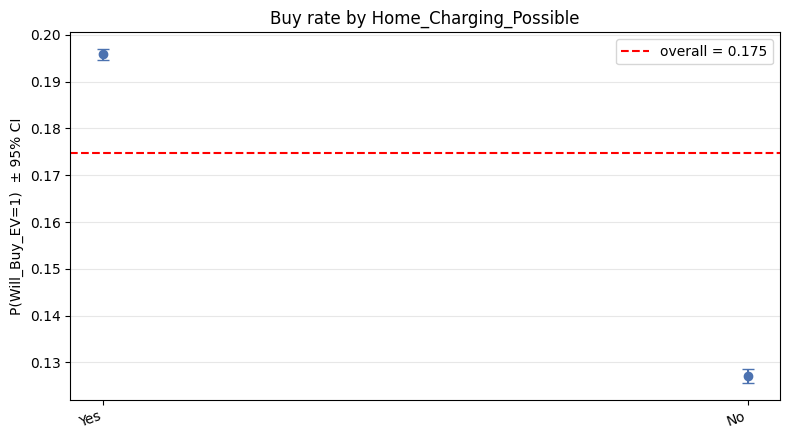


Home_Charging_Possible:
                          mean   count      se   ci_lo   ci_hi
Home_Charging_Possible                                        
Yes                     0.1958  462677  0.0006  0.1947  0.1970
No                      0.1271  205988  0.0007  0.1256  0.1285


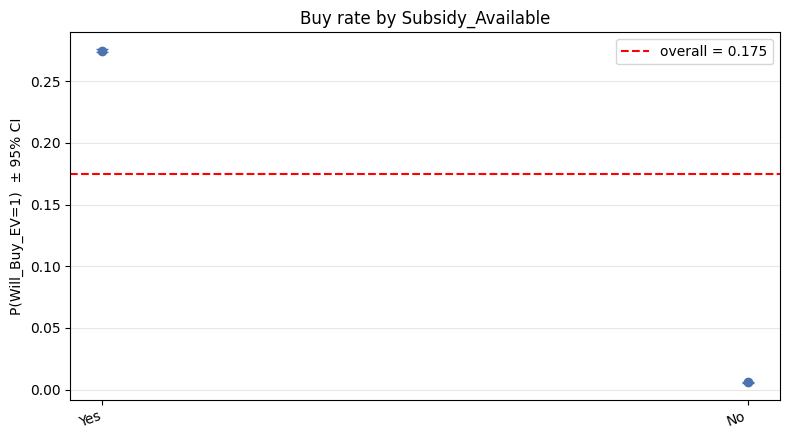


Subsidy_Available:
                     mean   count      se   ci_lo   ci_hi
Subsidy_Available                                        
Yes                0.2747  419909  0.0007  0.2733  0.2760
No                 0.0058  248756  0.0002  0.0055  0.0061


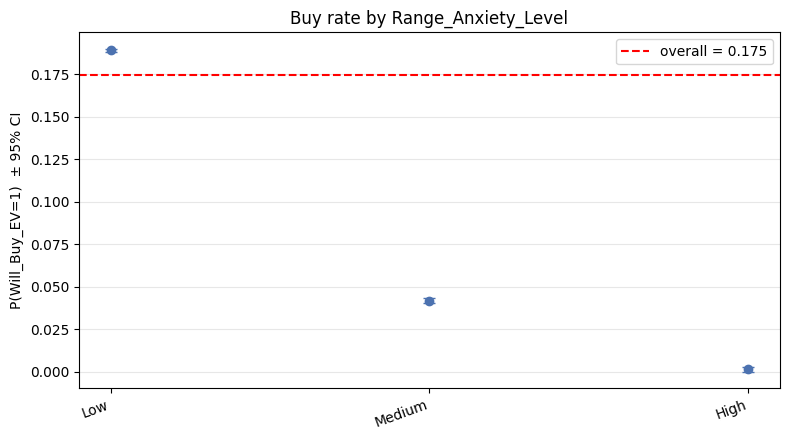


Range_Anxiety_Level:
                       mean   count      se   ci_lo   ci_hi
Range_Anxiety_Level                                        
Low                  0.1890  603972  0.0005  0.1880  0.1900
Medium               0.0417   62499  0.0008  0.0402  0.0433
High                 0.0014    2194  0.0008 -0.0002  0.0029


In [28]:
overall = train[TARGET].mean()
cat_rate_tables = {}

for c in cat_cols:
    g = train.groupby(c)[TARGET].agg(["mean", "count"])
    g["se"] = np.sqrt(g["mean"] * (1 - g["mean"]) / g["count"])
    g["ci_lo"] = g["mean"] - 1.96 * g["se"]
    g["ci_hi"] = g["mean"] + 1.96 * g["se"]
    g = g.sort_values("mean", ascending=False)
    cat_rate_tables[c] = g

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(g))
    ax.errorbar(x, g["mean"], yerr=1.96 * g["se"],
                fmt="o", capsize=4, color="#4C72B0")
    ax.axhline(overall, color="red", ls="--",
               label=f"overall = {overall:.3f}")
    ax.set_xticks(x)
    ax.set_xticklabels(g.index, rotation=20, ha="right")
    ax.set_ylabel(f"P({TARGET}=1)  ± 95% CI")
    ax.set_title(f"Buy rate by {c}")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/buyrate_cat_{c}.png", dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"\n{c}:")
    print(g.round(4))

# CHI-SQUARE TEST OF INDEPENDENCE

In [29]:
from scipy.stats import chi2_contingency

chi_rows = []
for c in cat_cols:
    ct = pd.crosstab(train[c], train[TARGET])
    chi2, p, dof, expected = chi2_contingency(ct)
    # Cramér's V as effect size (0 = no assoc, 1 = perfect)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi_rows.append({
        "feature": c,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "cramers_v": cramers_v,
    })

chi_df = pd.DataFrame(chi_rows).sort_values("cramers_v", ascending=False)
print(chi_df.to_string(index=False))
chi_df.to_csv(f"{PLOT_PATH}/chi_square_results.csv", index=False)

               feature         chi2       p_value  dof  cramers_v
     Subsidy_Available 78382.499544  0.000000e+00    1   0.342378
   Range_Anxiety_Level  8981.912549  0.000000e+00    2   0.115899
Home_Charging_Possible  4671.041365  0.000000e+00    1   0.083580
             City_Type   742.830196 4.971328e-162    2   0.033330
      Current_Car_Type   173.662580  2.060262e-37    3   0.016116
                Gender    33.040870  6.687538e-08    2   0.007029


# MUTUAL INFORMATION WITH TARGET

Environmental_Concern_Level    0.14761
Subsidy_Available              0.08082
Annual_Income_USD              0.05389
Number_of_Cars_Owned           0.04215
Range_Anxiety_Level            0.00903
Charging_Stations_Near_Home    0.00812
Daily_Commute_km               0.00568
Charging_Stations_Near_Work    0.00527
Age                            0.00387
Home_Charging_Possible         0.00366
City_Type                      0.00055
Current_Car_Type               0.00013
Gender                         0.00002


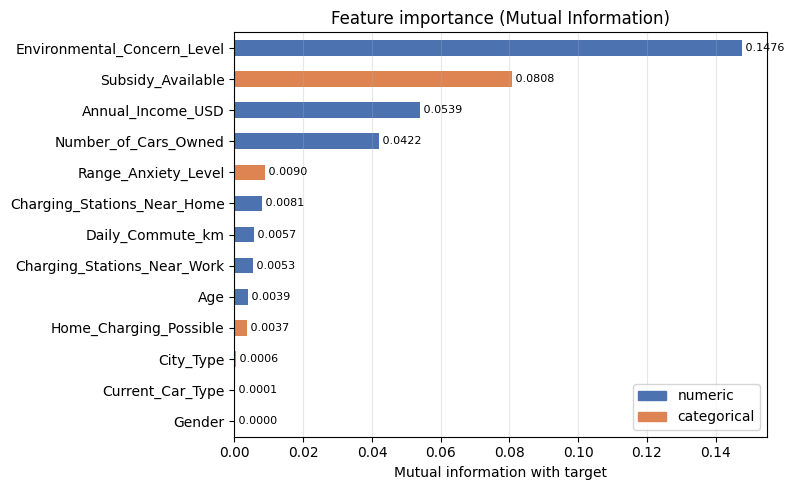

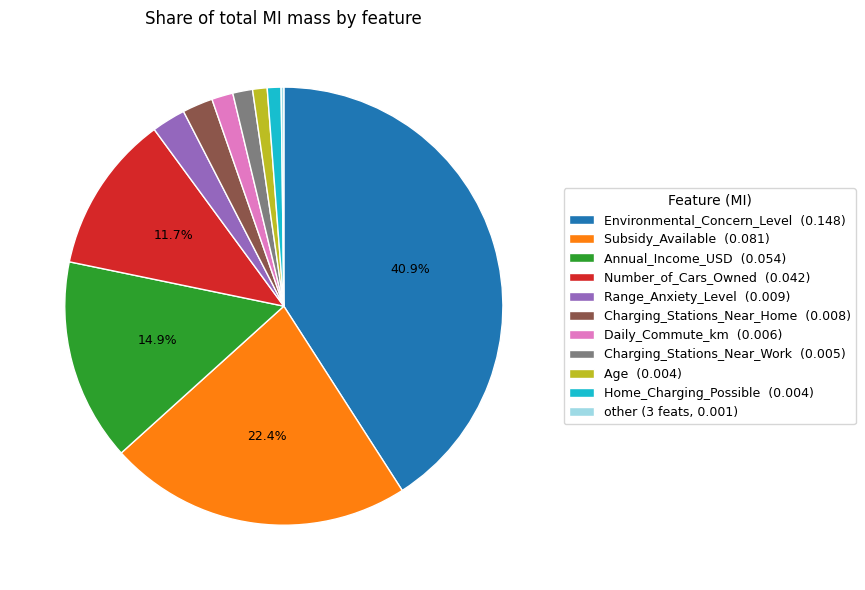

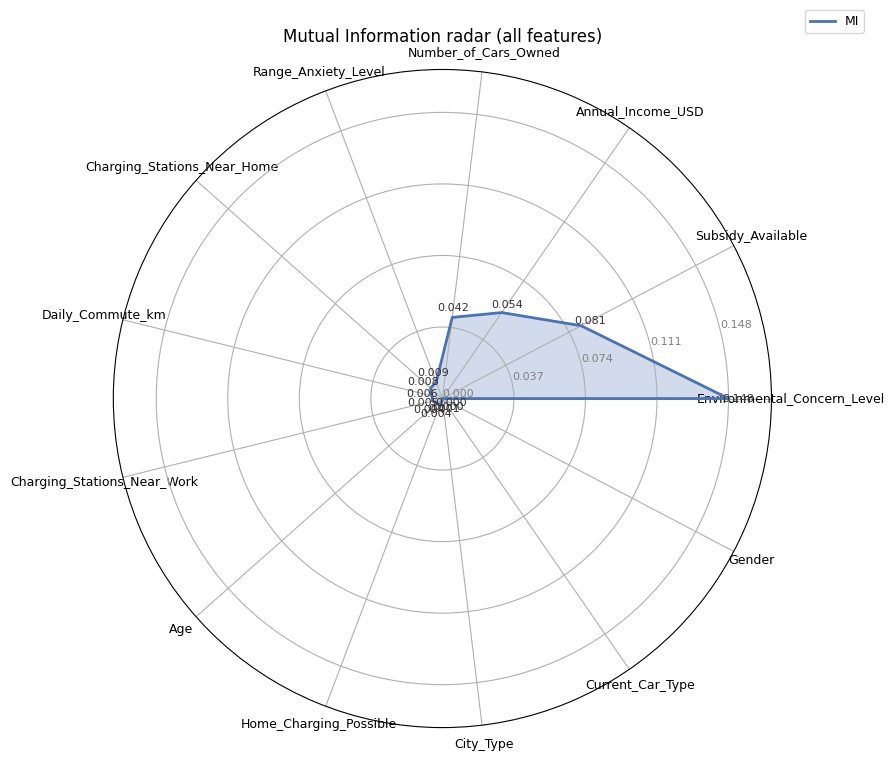

In [30]:
from sklearn.feature_selection import mutual_info_classif

#  MI computation 
X_all = train[num_cols + cat_cols].copy()

for c in num_cols:
    if X_all[c].isna().any():
        X_all[f"{c}__isna"] = X_all[c].isna().astype(int)
        X_all[c] = X_all[c].fillna(X_all[c].median())

for c in cat_cols:
    X_all[c] = X_all[c].fillna("__MISSING__").astype("category").cat.codes

discrete_mask = [c in cat_cols for c in X_all.columns]

y = train[TARGET].values
assert not pd.isna(y).any(), "Target has NaN"

mi = mutual_info_classif(
    X_all, y,
    discrete_features=discrete_mask,
    random_state=42,
)
mi_series = pd.Series(mi, index=X_all.columns).sort_values(ascending=False)
print(mi_series.round(5).to_string())

# BAR CHART (your existing one)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#DD8452" if c in cat_cols else "#4C72B0" for c in mi_series.index]
mi_series.plot.barh(ax=ax, color=colors)
ax.invert_yaxis()

for i, v in enumerate(mi_series.values):
    ax.text(v, i, f" {v:.4f}", va="center", fontsize=8)

ax.set_xlabel("Mutual information with target")
ax.set_title("Feature importance (Mutual Information)")
ax.grid(alpha=0.3, axis="x")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#4C72B0", label="numeric"),
    Patch(color="#DD8452", label="categorical"),
], loc="lower right")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/mutual_information_bar.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

# PIE CHART — share of total MI mass
THRESHOLD = mi_series.sum() * 0.005                                 # features < 0.5% of total → "other"
big   = mi_series[mi_series >= THRESHOLD]
small = mi_series[mi_series <  THRESHOLD]

pie_vals = list(big.values)
pie_lbls = [f"{n}  ({v:.3f})" for n, v in big.items()]
if len(small) > 0:
    pie_vals.append(small.sum())
    pie_lbls.append(f"other ({len(small)} feats, {small.sum():.3f})")

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(pie_vals)))
wedges, _, autotexts = ax.pie(
    pie_vals,
    labels=None,
    autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",
    startangle=90, counterclock=False,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    textprops=dict(fontsize=9),
)
ax.legend(wedges, pie_lbls, title="Feature (MI)",
          loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
ax.set_title("Share of total MI mass by feature", fontsize=12)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/mutual_information_pie.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# RADAR CHART — MI profile across features
labels = mi_series.index.tolist()
vals   = mi_series.values
n = len(labels)

angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
angles += angles[:1]
vals_plot = vals.tolist() + [vals[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.plot(angles, vals_plot, color="#4C72B0", linewidth=2, label="MI")
ax.fill(angles, vals_plot, color="#4C72B0", alpha=0.25)

# annotate each vertex
for ang, v in zip(angles[:-1], vals):
    ax.text(ang, v + 0.005, f"{v:.3f}",
            ha="center", va="center", fontsize=8, color="#333")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, max(vals)*1.15)
ax.set_yticks(np.linspace(0, max(vals), 5))
ax.set_yticklabels([f"{v:.3f}" for v in np.linspace(0, max(vals), 5)],
                   fontsize=8, color="gray")
ax.set_rlabel_position(180 / n)
ax.set_title("Mutual Information radar (all features)", fontsize=12, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.10), fontsize=9)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/mutual_information_radar.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# FEATURE-FEATURE CORRELATION (numeric only) + VIF

Top correlated numeric pairs:
                                                           corr
Charging_Stations_Near_Home Charging_Stations_Near_Work  0.5111
Annual_Income_USD           Environmental_Concern_Level  0.0764
Daily_Commute_km            Charging_Stations_Near_Home  0.0452
                            Charging_Stations_Near_Work  0.0350
                            Environmental_Concern_Level -0.0189
Charging_Stations_Near_Home Environmental_Concern_Level -0.0113
Annual_Income_USD           Charging_Stations_Near_Home -0.0086
Number_of_Cars_Owned        Charging_Stations_Near_Work  0.0086
                            Charging_Stations_Near_Home  0.0085
Annual_Income_USD           Daily_Commute_km             0.0080
Charging_Stations_Near_Work Environmental_Concern_Level -0.0078
Age                         Daily_Commute_km            -0.0065
                            Charging_Stations_Near_Work -0.0059
                            Annual_Income_USD           -0.0046
          

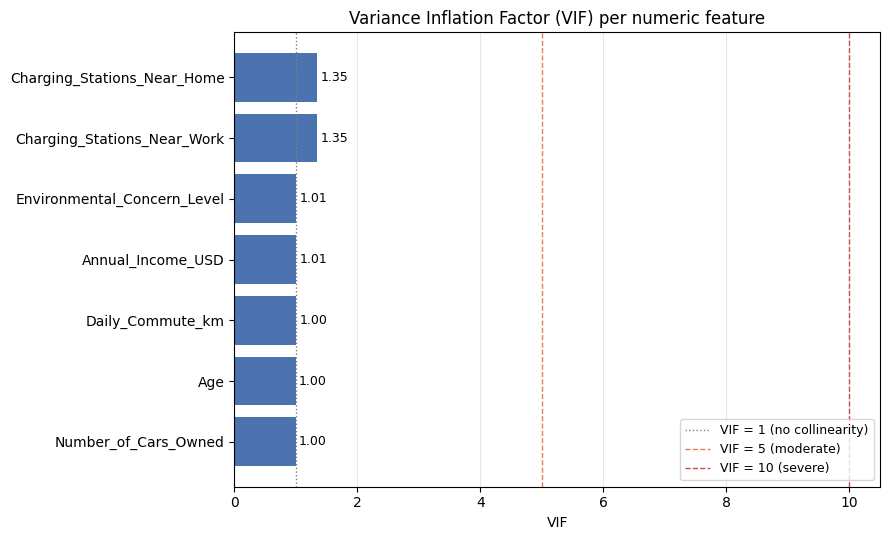

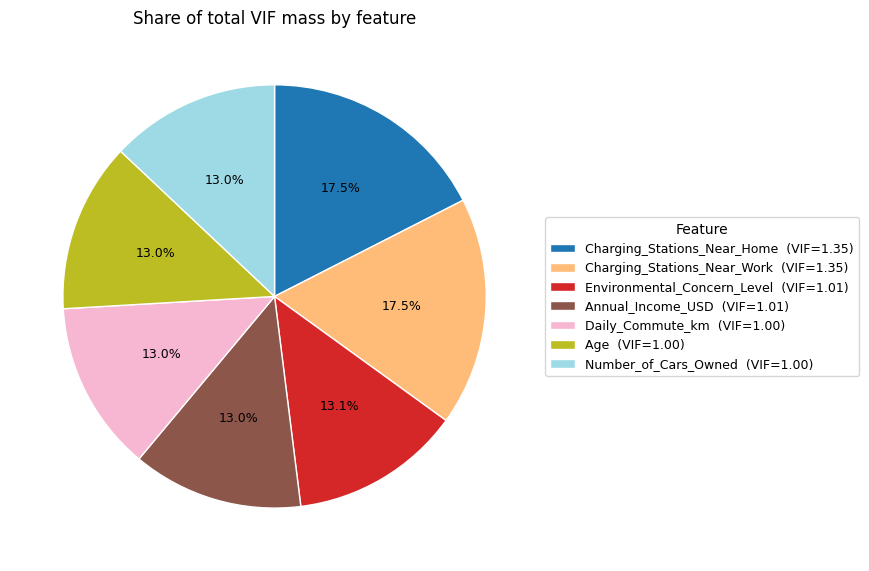

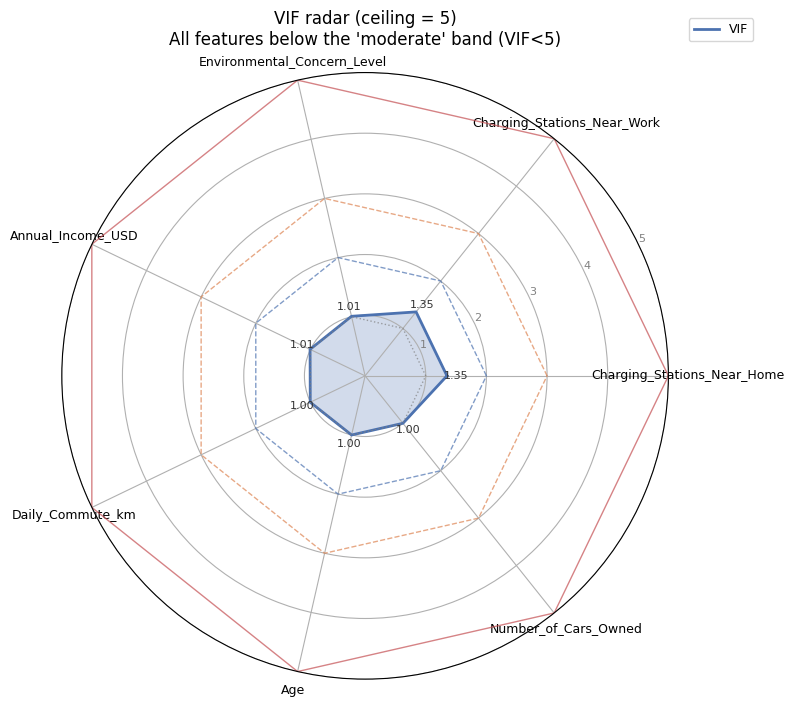

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Correlation (unchanged, cleaned up) 
corr = train[num_cols].corr()

mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = (
    corr.where(mask)
         .stack()
         .rename("corr")
         .to_frame()
         .assign(abs_corr=lambda d: d["corr"].abs())
         .sort_values("abs_corr", ascending=False)
         .drop(columns="abs_corr")
)
print("Top correlated numeric pairs:")
print(pairs.head(15).round(4).to_string())

# VIF (unchanged, NaN-safe) 
sample = train[num_cols].sample(min(50_000, len(train)), random_state=42).copy()
sample = sample.fillna(sample.median(numeric_only=True))
sample = sample.replace([np.inf, -np.inf], np.nan).dropna()

X_vif = add_constant(sample, has_constant="add")
vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=X_vif.columns,
).drop("const").sort_values(ascending=False)

print("\nVIF:")
print(vif.round(3).to_string())

#  BAR CHART — VIF per feature with severity bands
def vif_color(v):
    if v < 5:   return "#4C72B0"   # fine
    if v < 10:  return "#DD8452"   # watch
    return "#C44E52"               # problem

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(vif.index, vif.values, color=[vif_color(v) for v in vif.values])
ax.invert_yaxis()

# reference lines
ax.axvline(1,  color="gray",    ls=":",  lw=1, label="VIF = 1 (no collinearity)")
ax.axvline(5,  color="#DD8452", ls="--", lw=1, label="VIF = 5 (moderate)")
ax.axvline(10, color="#C44E52", ls="--", lw=1, label="VIF = 10 (severe)")

# value labels
for b, v in zip(bars, vif.values):
    ax.text(v + 0.05, b.get_y() + b.get_height()/2,
            f"{v:.2f}", va="center", fontsize=9)

ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor (VIF) per numeric feature")
ax.grid(alpha=0.3, axis="x")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/vif_bar.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

#  PIE CHART — share of total VIF mass per feature(shows which features dominate the collinearity "budget")
vif_pos = vif.clip(lower=0)                                 # VIF is always >= 1 in practice, but guard anyway

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(vif_pos)))
wedges, _, autotexts = ax.pie(
    vif_pos.values,
    labels=None,                                            # use legend instead to avoid crowding
    autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",        # hide tiny slices
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    textprops=dict(fontsize=9),
)
ax.legend(
    wedges,
    [f"{name}  (VIF={val:.2f})" for name, val in zip(vif_pos.index, vif_pos.values)],
    title="Feature",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9,
)
ax.set_title("Share of total VIF mass by feature", fontsize=12)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/vif_pie.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# Use ceiling=5 so the 1-3 range spreads visibly; cap anything above at 5.
CEIL = 5.0

labels = vif.index.tolist()
values = np.clip(vif.values, 0, CEIL)
n = len(labels)

# angles: close the loop by repeating first point
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]
values_plot = values.tolist() + [values[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# main polygon 
ax.plot(angles, values_plot, color="#4C72B0", linewidth=2, label="VIF")
ax.fill(angles, values_plot, color="#4C72B0", alpha=0.25)

# reference rings for severity 
for ref, color, style in [(1, "gray", ":"), (2, "#4C72B0", "--"),
                          (3, "#DD8452", "--"), (5, "#C44E52", "-")]:
    if ref <= CEIL:
        ax.plot(angles, [ref] * (n + 1), color=color, ls=style,
                lw=1, alpha=0.7)

# tick labels at each feature 
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)

# radial grid 
ax.set_ylim(0, CEIL)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=8, color="gray")
ax.set_rlabel_position(180 / n)  # move radial labels off the first axis

# annotate each vertex with the true VIF value 
for ang, v, true_v in zip(angles[:-1], values, vif.values):
    ax.text(ang, v + 0.15, f"{true_v:.2f}",
            ha="center", va="center", fontsize=8, color="#333")

ax.set_title("VIF radar (ceiling = 5)\nAll features below the 'moderate' band (VIF<5)",
             fontsize=12, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.10), fontsize=9)

plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/vif_radar.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# NUMERIC x CATEGORICAL INTERACTIONS

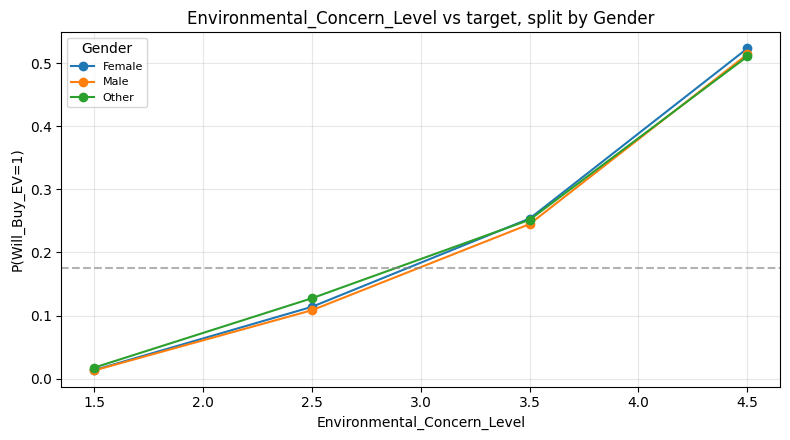

Saved ./plots/interaction_Environmental_Concern_Level_x_Gender.png


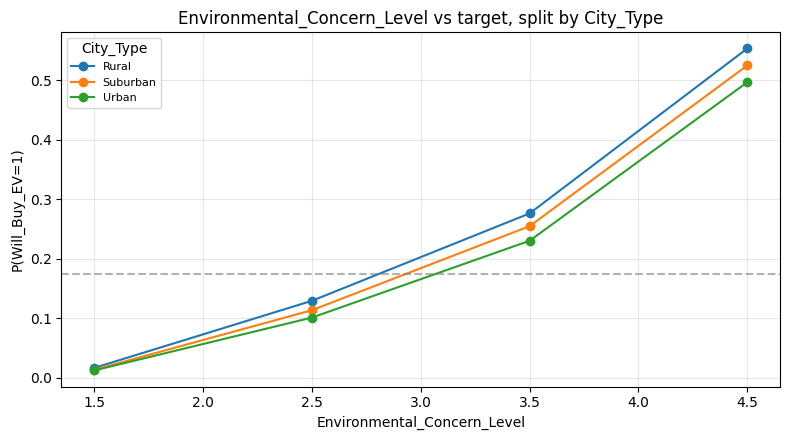

Saved ./plots/interaction_Environmental_Concern_Level_x_City_Type.png


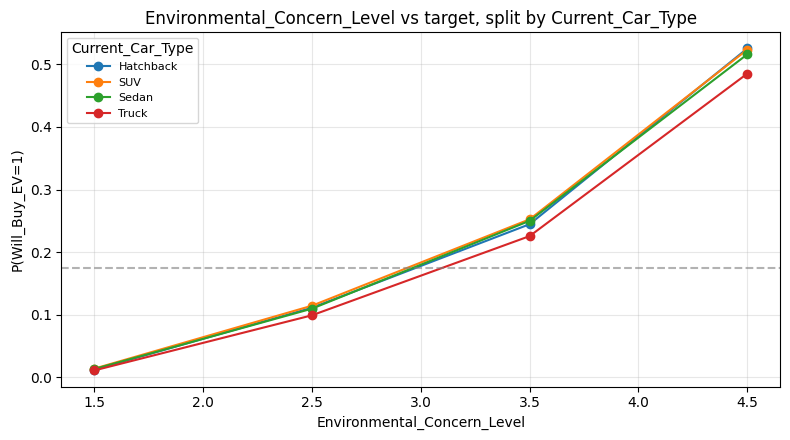

Saved ./plots/interaction_Environmental_Concern_Level_x_Current_Car_Type.png


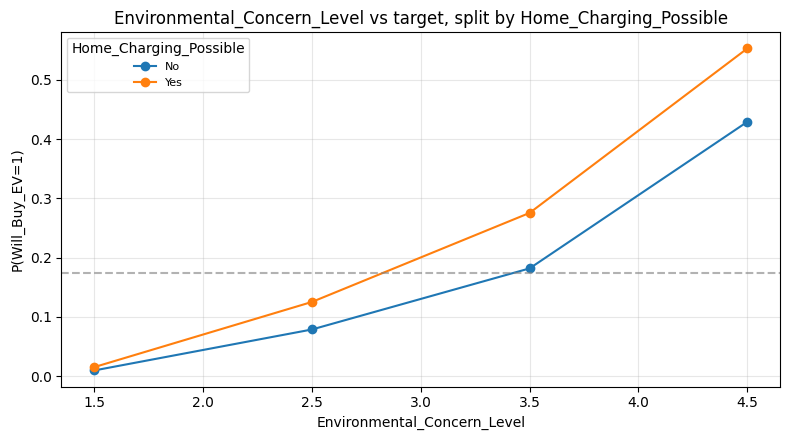

Saved ./plots/interaction_Environmental_Concern_Level_x_Home_Charging_Possible.png


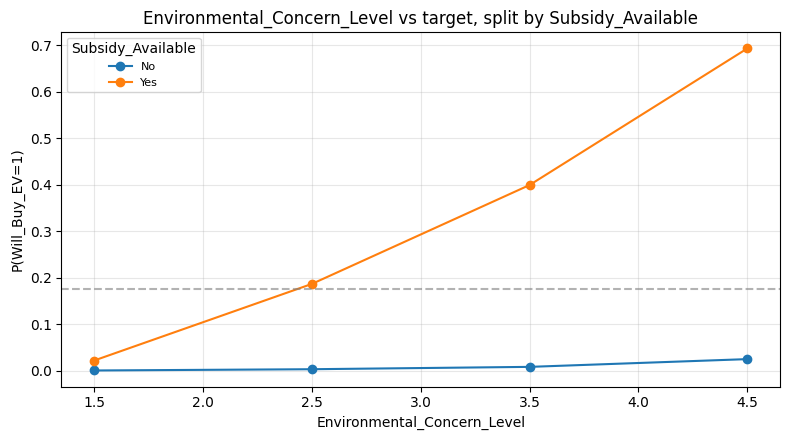

Saved ./plots/interaction_Environmental_Concern_Level_x_Subsidy_Available.png


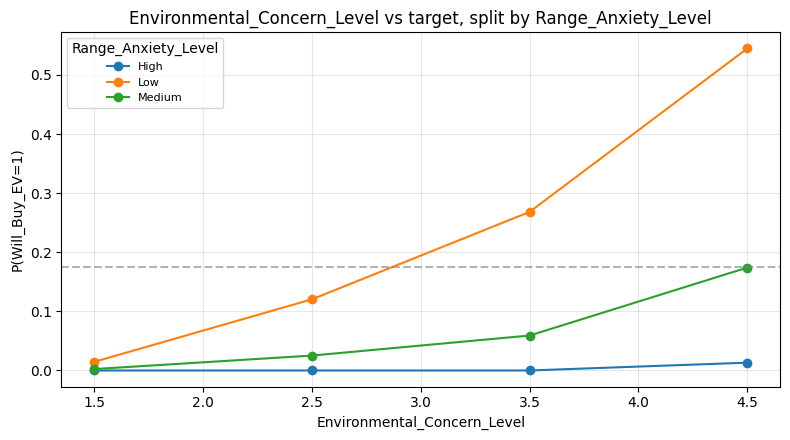

Saved ./plots/interaction_Environmental_Concern_Level_x_Range_Anxiety_Level.png


In [32]:
# Pick the strongest numeric feature (from MI / Pearson) and check
# whether its relationship with the target changes across categories.
strong_numeric = mi_series.head(2).index.tolist()
strong_numeric = [c for c in strong_numeric if c in num_cols]

for num_c in strong_numeric:
    for cat_c in cat_cols:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for cat_val, sub in train.groupby(cat_c):
            # bin numeric, compute rate within this category
            try:
                binned = pd.qcut(sub[num_c], q=6, duplicates="drop")
            except ValueError:
                continue
            rate = sub.groupby(binned, observed=True)[TARGET].mean()
            mids = [iv.mid for iv in rate.index]
            ax.plot(mids, rate.values, marker="o", label=str(cat_val))
        ax.axhline(train[TARGET].mean(), color="grey", ls="--", alpha=0.6)
        ax.set_xlabel(num_c)
        ax.set_ylabel(f"P({TARGET}=1)")
        ax.set_title(f"{num_c} vs target, split by {cat_c}")
        ax.legend(title=cat_c, fontsize=8)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        fname = f"{PLOT_PATH}/interaction_{num_c}_x_{cat_c}.png"
        plt.savefig(fname, dpi=110, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Saved {fname}")

# PAIRPLOT OF TOP FEATURES

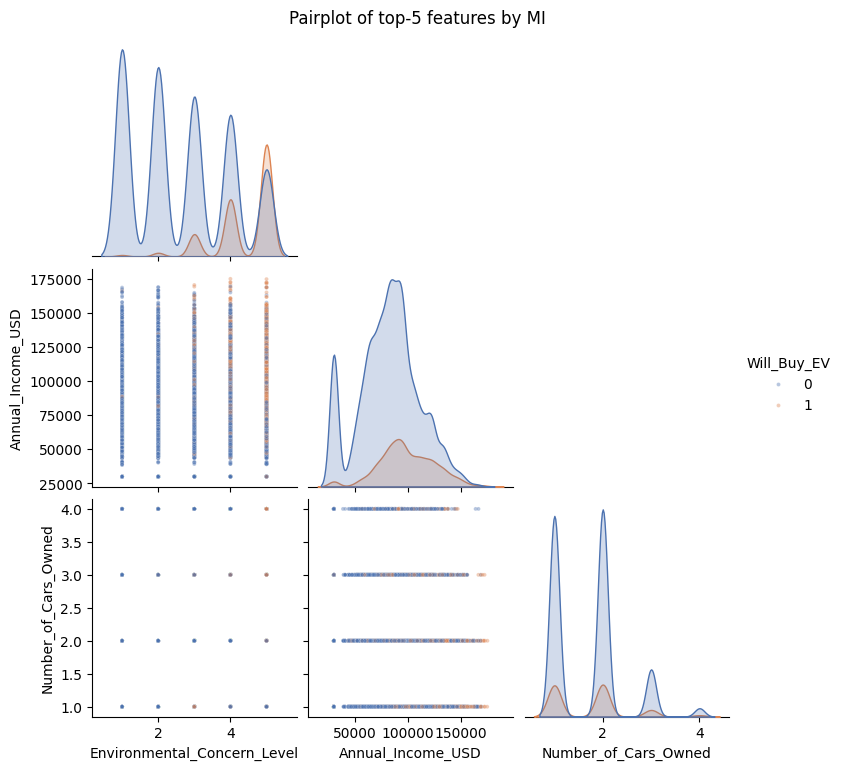

In [33]:
PALETTE = {0: "#4C72B0", 1: "#DD8452"}

top_feats = mi_series.head(5).index.tolist()
sample = train.sample(min(20000, len(train)), random_state=42)

g = sns.pairplot(
    sample[top_feats + [TARGET]],
    hue=TARGET,
    palette=PALETTE,
    corner=True,
    plot_kws={"s": 8, "alpha": 0.4},
    diag_kind="kde",
)
g.fig.suptitle("Pairplot of top-5 features by MI", y=1.02)
g.savefig(f"{PLOT_PATH}/pairplot_top_features.png", dpi=110, bbox_inches="tight")
plt.show()
plt.close()

# BUY RATE PER SEGMENT (2-way)


Gender x City_Type: buy rate
City_Type  Rural  Suburban  Urban
Gender                           
Female     0.196     0.184  0.164
Male       0.191     0.179  0.159
Other      0.205     0.180  0.156


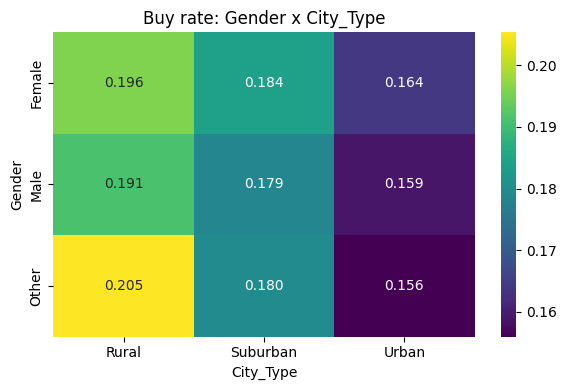


Gender x Current_Car_Type: buy rate
Current_Car_Type  Hatchback    SUV  Sedan  Truck
Gender                                          
Female                0.175  0.183  0.176  0.163
Male                  0.174  0.179  0.169  0.151
Other                 0.172  0.178  0.172  0.169


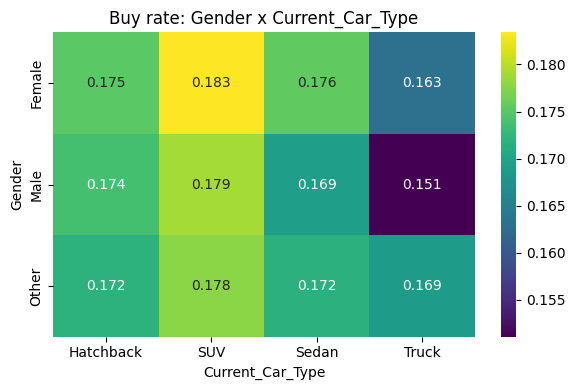


Gender x Home_Charging_Possible: buy rate
Home_Charging_Possible     No    Yes
Gender                              
Female                  0.130  0.198
Male                    0.125  0.194
Other                   0.134  0.193


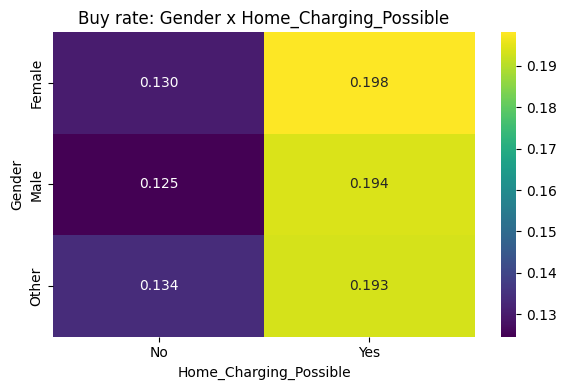


Gender x Subsidy_Available: buy rate
Subsidy_Available     No    Yes
Gender                         
Female             0.006  0.278
Male               0.006  0.272
Other              0.007  0.271


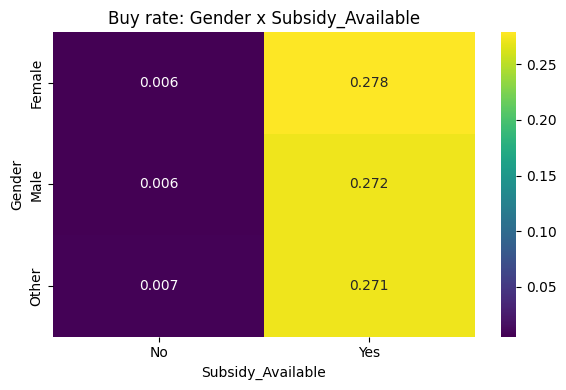


Gender x Range_Anxiety_Level: buy rate
Range_Anxiety_Level   High    Low  Medium
Gender                                   
Female               0.001  0.192   0.043
Male                 0.002  0.187   0.041
Other                0.000  0.189   0.041


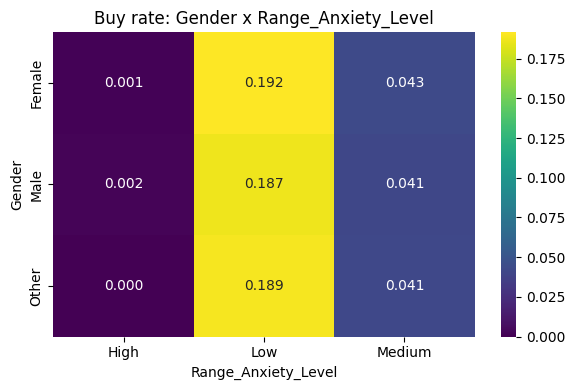


City_Type x Current_Car_Type: buy rate
Current_Car_Type  Hatchback    SUV  Sedan  Truck
City_Type                                       
Rural                 0.195  0.197  0.192  0.177
Suburban              0.180  0.189  0.177  0.161
Urban                 0.160  0.166  0.159  0.144


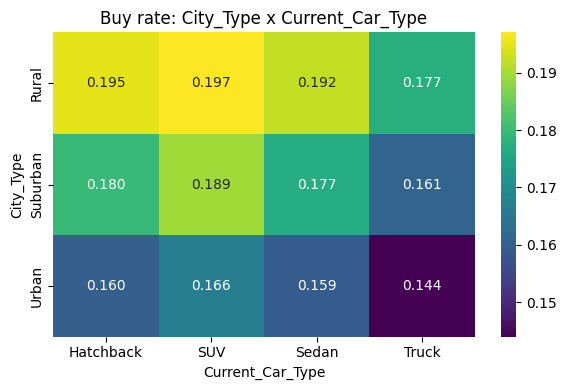


City_Type x Home_Charging_Possible: buy rate
Home_Charging_Possible     No    Yes
City_Type                           
Rural                   0.046  0.198
Suburban                0.082  0.192
Urban                   0.136  0.200


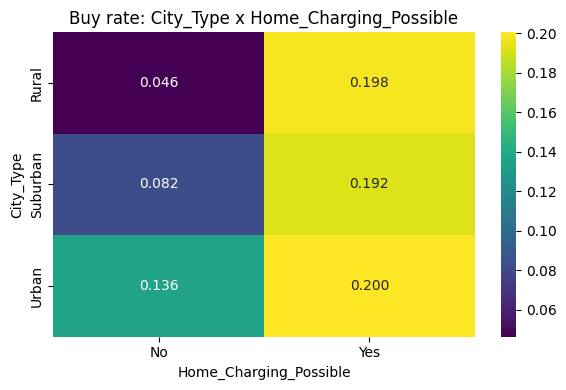


City_Type x Subsidy_Available: buy rate
Subsidy_Available     No    Yes
City_Type                      
Rural              0.007  0.293
Suburban           0.006  0.285
Urban              0.005  0.257


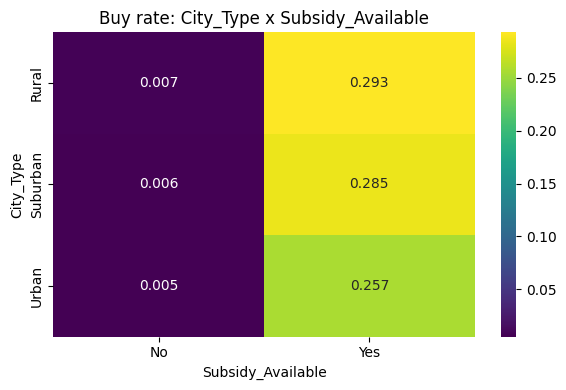


City_Type x Range_Anxiety_Level: buy rate
Range_Anxiety_Level   High    Low  Medium
City_Type                                
Rural                0.002  0.199   0.041
Suburban             0.001  0.192   0.040
Urban                0.002  0.182   0.042


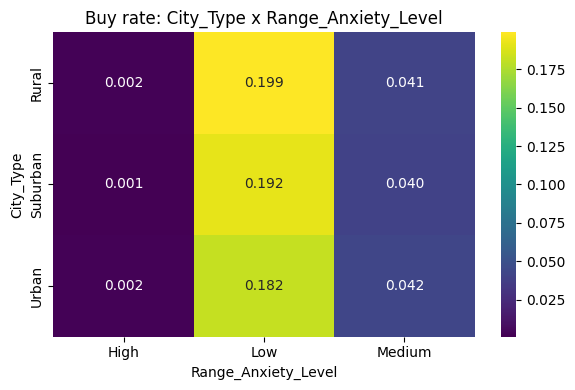


Current_Car_Type x Home_Charging_Possible: buy rate
Home_Charging_Possible     No    Yes
Current_Car_Type                    
Hatchback               0.125  0.194
SUV                     0.133  0.202
Sedan                   0.125  0.193
Truck                   0.113  0.178


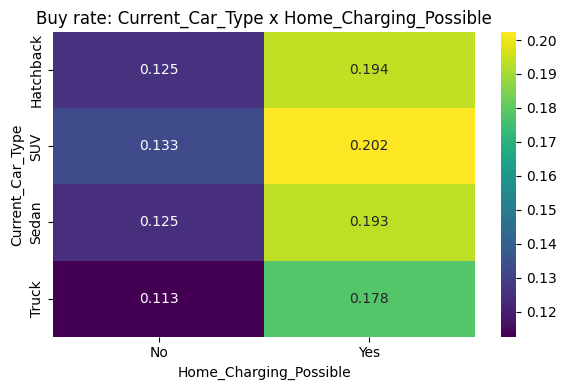


Current_Car_Type x Subsidy_Available: buy rate
Subsidy_Available     No    Yes
Current_Car_Type               
Hatchback          0.005  0.273
SUV                0.006  0.281
Sedan              0.006  0.273
Truck              0.006  0.247


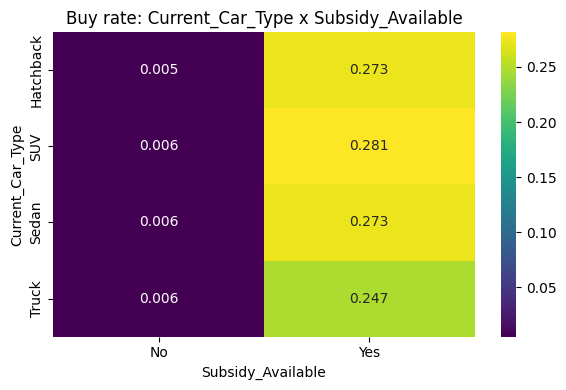


Current_Car_Type x Range_Anxiety_Level: buy rate
Range_Anxiety_Level   High    Low  Medium
Current_Car_Type                         
Hatchback            0.000  0.188   0.043
SUV                  0.001  0.195   0.043
Sedan                0.002  0.186   0.041
Truck                0.000  0.171   0.039


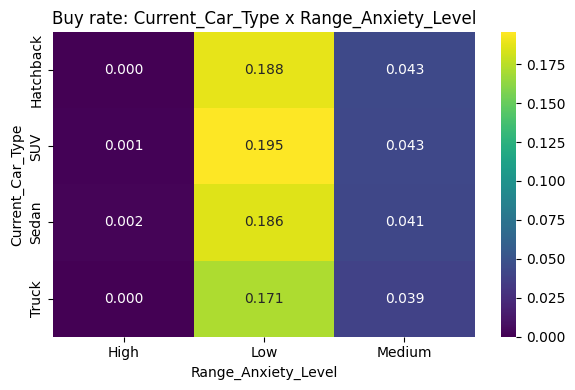


Home_Charging_Possible x Subsidy_Available: buy rate
Subsidy_Available          No    Yes
Home_Charging_Possible              
No                      0.004  0.206
Yes                     0.007  0.304


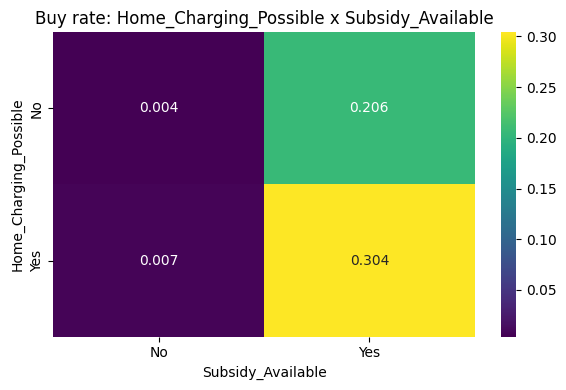


Home_Charging_Possible x Range_Anxiety_Level: buy rate
Range_Anxiety_Level      High    Low  Medium
Home_Charging_Possible                      
No                      0.001  0.166   0.042
Yes                       NaN  0.196   0.047


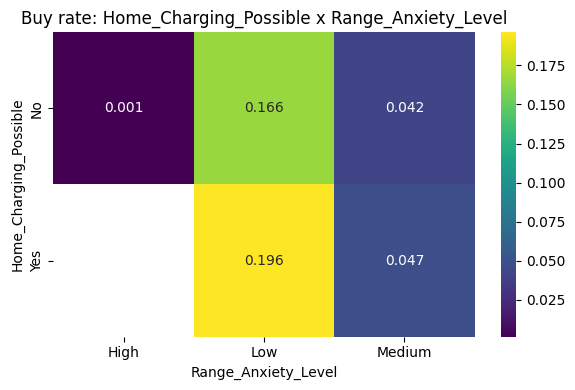


Subsidy_Available x Range_Anxiety_Level: buy rate
Range_Anxiety_Level   High    Low  Medium
Subsidy_Available                        
No                   0.000  0.006   0.001
Yes                  0.002  0.296   0.069


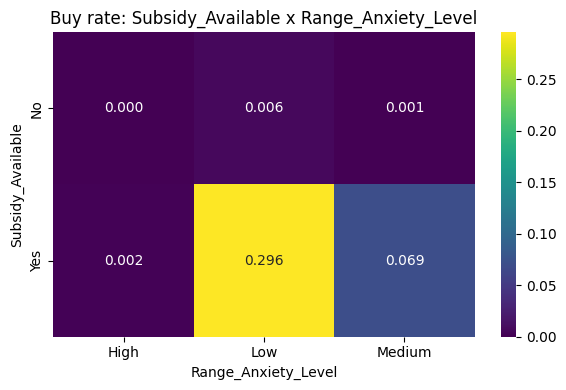

In [34]:
from itertools import combinations

for c1, c2 in combinations(cat_cols, 2):
    ct = train.pivot_table(
        index=c1, columns=c2, values=TARGET, aggfunc="mean"
    )
    print(f"\n{c1} x {c2}: buy rate")
    print(ct.round(3))

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(ct, annot=True, fmt=".3f", cmap="viridis", ax=ax)
    ax.set_title(f"Buy rate: {c1} x {c2}")
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/heatmap_{c1}_x_{c2}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# MANN-WHITNEY U TEST

In [35]:
from scipy.stats import mannwhitneyu

mw_rows = []
for c in num_cols:
    a = train.loc[train[TARGET] == 1, c]
    b = train.loc[train[TARGET] == 0, c]
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    # Rank-biserial correlation as effect size
    n1, n2 = len(a), len(b)
    rbc = 1 - (2 * stat) / (n1 * n2)
    mw_rows.append({
        "feature": c,
        "U": stat,
        "p_value": p,
        "rank_biserial": rbc,
        "median_yes": a.median(),
        "median_no": b.median(),
    })

mw_df = pd.DataFrame(mw_rows).sort_values("rank_biserial", key=np.abs, ascending=False)
print(mw_df.to_string(index=False))
mw_df.to_csv(f"{PLOT_PATH}/mannwhitney_results.csv", index=False)

                    feature            U       p_value  rank_biserial  median_yes  median_no
Environmental_Concern_Level 5.436385e+10  0.000000e+00      -0.687043         5.0        2.0
          Annual_Income_USD 4.320426e+10  0.000000e+00      -0.340734     96167.0    82844.0
           Daily_Commute_km 3.004876e+10 1.722797e-291       0.067514        31.7       34.0
Charging_Stations_Near_Home 3.120050e+10  5.193597e-66       0.031773         4.0        4.0
Charging_Stations_Near_Work 3.153992e+10  2.346429e-30       0.021240         6.0        6.0
                        Age 3.186759e+10  2.606006e-09       0.011071        47.0       47.0
       Number_of_Cars_Owned 3.247792e+10  3.418005e-06      -0.007869         2.0        2.0


# TARGET ENCODING PREVIEW (with smoothing)

In [36]:
prior = train[TARGET].mean()
k = 20  # smoothing factor

for c in cat_cols:
    g = train.groupby(c)[TARGET].agg(["mean", "count"])
    g["smoothed"] = (g["count"] * g["mean"] + k * prior) / (g["count"] + k)
    g = g.sort_values("smoothed", ascending=False)
    print(f"\n{c} target encoding (smoothed, k={k}):")
    print(g.round(4))


Gender target encoding (smoothed, k=20):
          mean   count  smoothed
Gender                          
Female  0.1776  295427    0.1776
Other   0.1737    5284    0.1737
Male    0.1723  367954    0.1723

City_Type target encoding (smoothed, k=20):
             mean   count  smoothed
City_Type                          
Rural      0.1934  123983    0.1934
Suburban   0.1809  255377    0.1809
Urban      0.1611  289305    0.1611

Current_Car_Type target encoding (smoothed, k=20):
                    mean   count  smoothed
Current_Car_Type                          
SUV               0.1810  246545    0.1810
Hatchback         0.1743   79438    0.1743
Sedan             0.1720  303459    0.1720
Truck             0.1564   39223    0.1564

Home_Charging_Possible target encoding (smoothed, k=20):
                          mean   count  smoothed
Home_Charging_Possible                          
Yes                     0.1958  462677    0.1958
No                      0.1271  205988    0.1271

Sub

# USELESS FEATURE DETECTION

In [38]:
report = []
for c in num_cols + cat_cols:
    nunique = train[c].nunique(dropna=False)
    top_share = train[c].value_counts(normalize=True, dropna=False).iloc[0]
    report.append({
        "feature": c,
        "nunique": nunique,
        "top_value_share": round(top_share, 4),
        "is_constant": nunique == 1,
        "is_near_constant": top_share > 0.99,
    })
print(pd.DataFrame(report).to_string(index=False))

                    feature  nunique  top_value_share  is_constant  is_near_constant
                        Age       45           0.0266        False             False
          Annual_Income_USD    13214           0.0921        False             False
           Daily_Commute_km      805           0.2158        False             False
       Number_of_Cars_Owned        4           0.4461        False             False
Charging_Stations_Near_Home       15           0.1519        False             False
Charging_Stations_Near_Work       20           0.1193        False             False
Environmental_Concern_Level        5           0.2206        False             False
                     Gender        3           0.5503        False             False
                  City_Type        3           0.4327        False             False
           Current_Car_Type        4           0.4538        False             False
     Home_Charging_Possible        2           0.6919        Fals

# TRAIN/TEST DISTRIBUTION SHIFT (KS TEST)

                    feature  KS_stat  p_value
Charging_Stations_Near_Work 0.003005 0.053355
                        Age 0.002293 0.241771
       Number_of_Cars_Owned 0.001660 0.637171
          Annual_Income_USD 0.001639 0.653217
Charging_Stations_Near_Home 0.001579 0.698836
Environmental_Concern_Level 0.001271 0.901569
           Daily_Commute_km 0.001067 0.976165


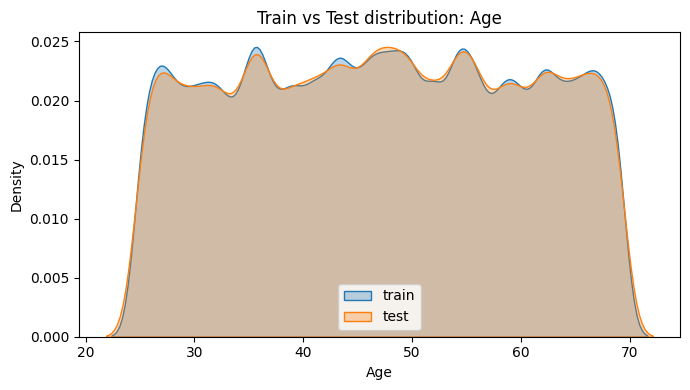

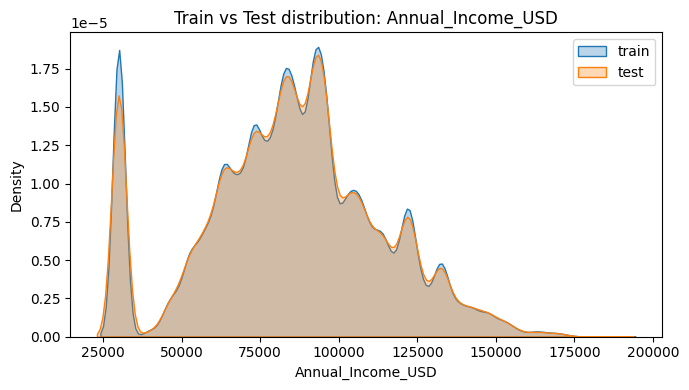

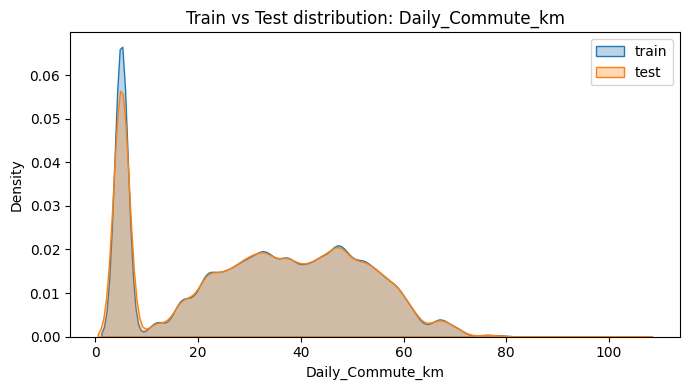

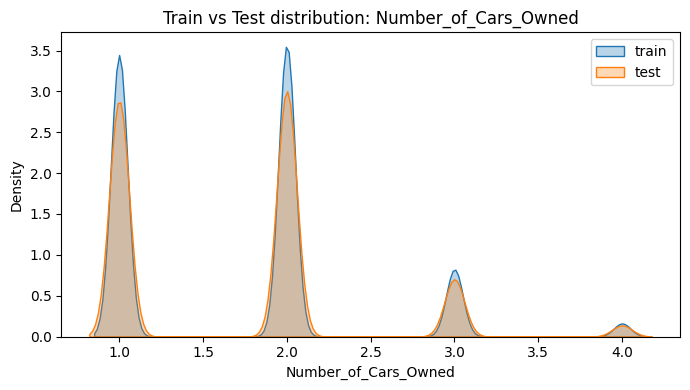

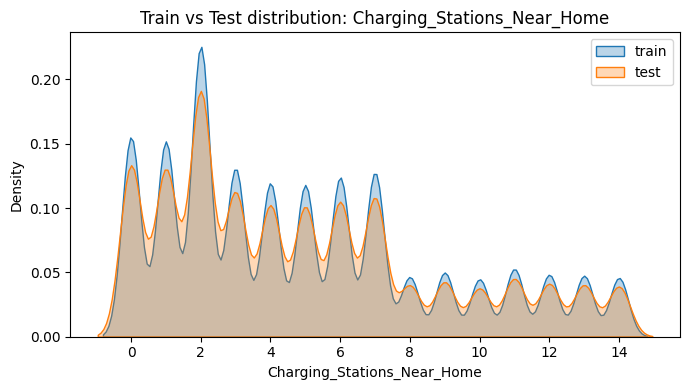

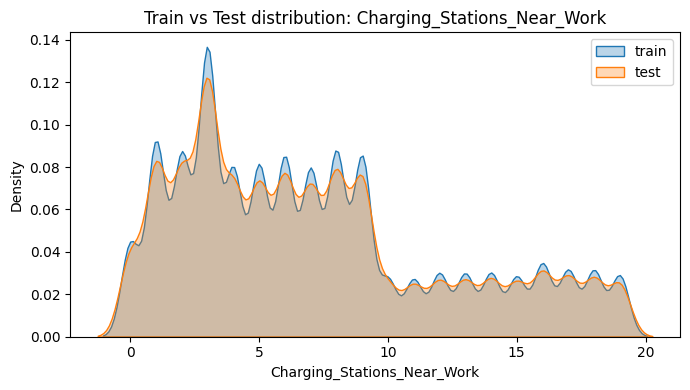

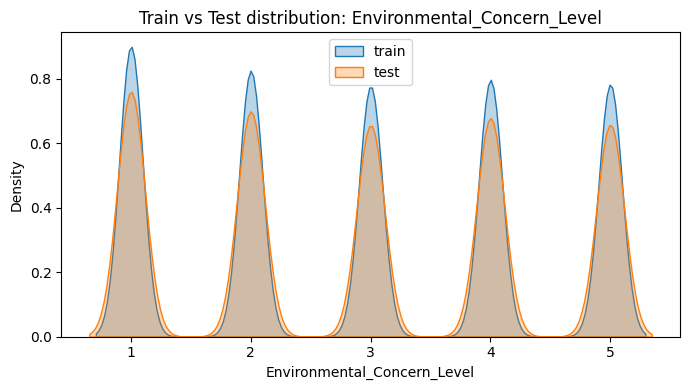

In [39]:
from scipy.stats import ks_2samp

shift_rows = []
for c in num_cols:
    stat, p = ks_2samp(train[c], test[c])
    shift_rows.append({"feature": c, "KS_stat": stat, "p_value": p})

shift_df = pd.DataFrame(shift_rows).sort_values("KS_stat", ascending=False)
print(shift_df.to_string(index=False))

for c in num_cols:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.kdeplot(train[c], label="train", ax=ax, fill=True, alpha=0.3)
    sns.kdeplot(test[c],  label="test",  ax=ax, fill=True, alpha=0.3)
    ax.set_title(f"Train vs Test distribution: {c}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/shift_{c}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# KDE OVERLAY: TRAIN (buy/no-buy) vs TEST

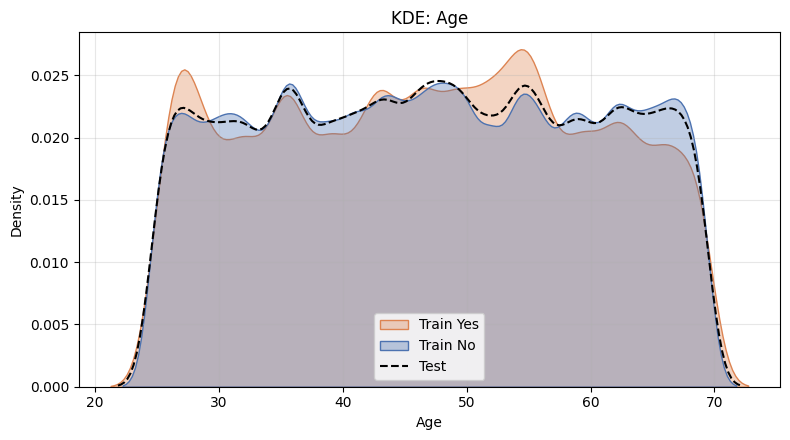

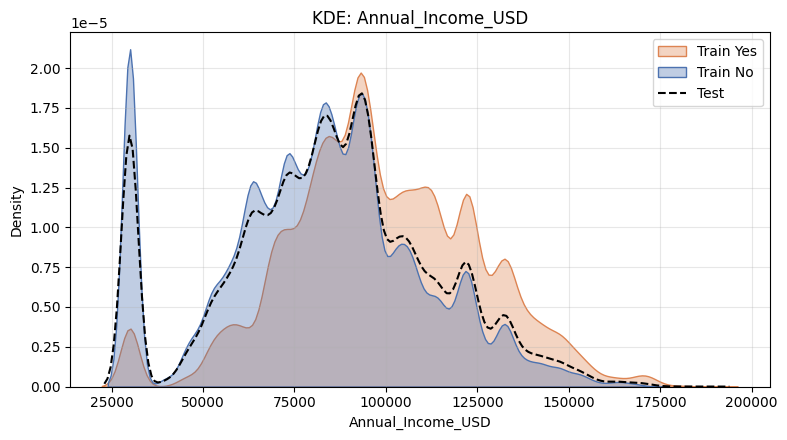

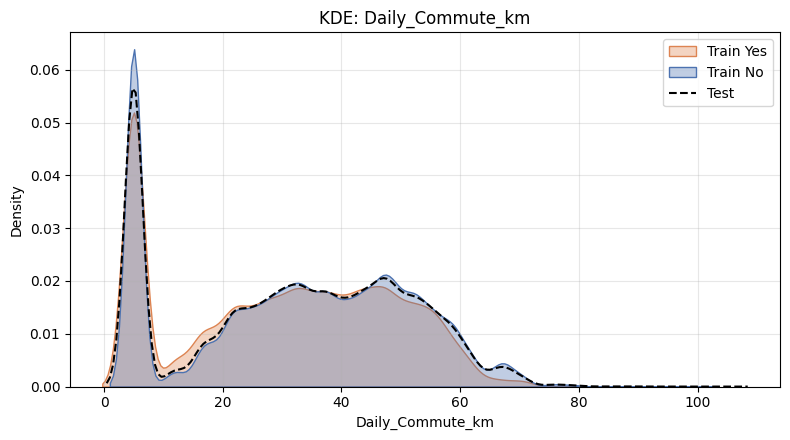

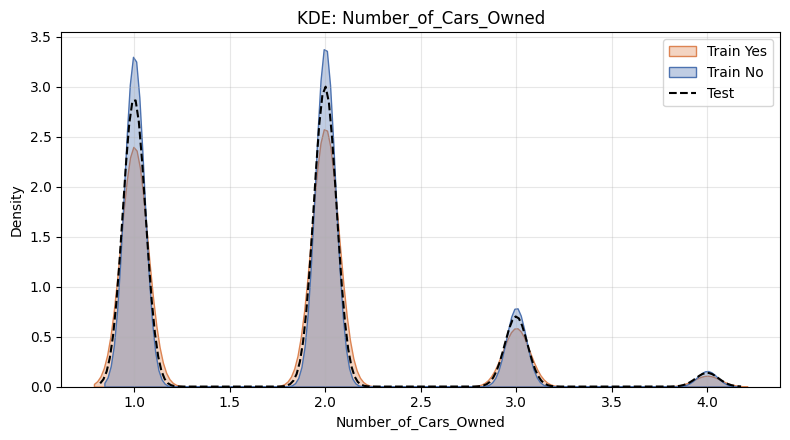

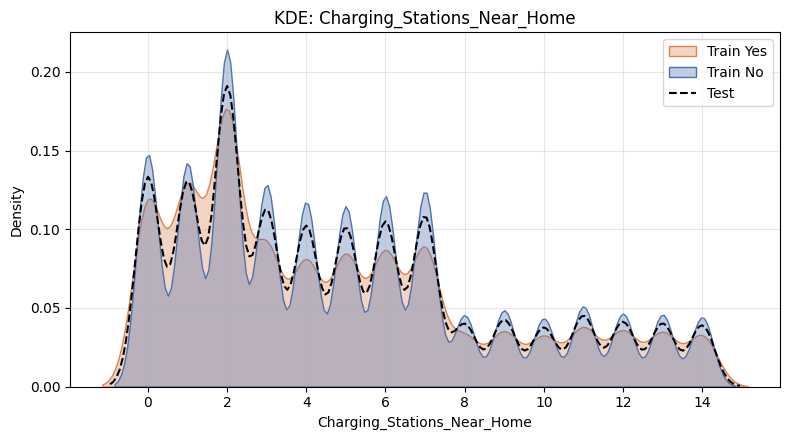

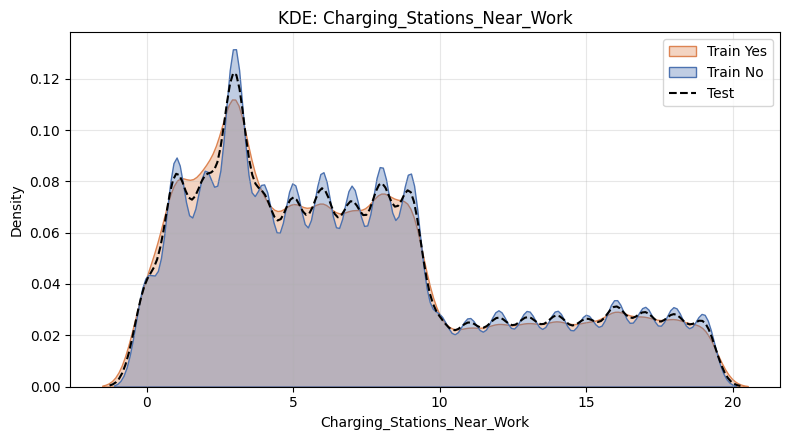

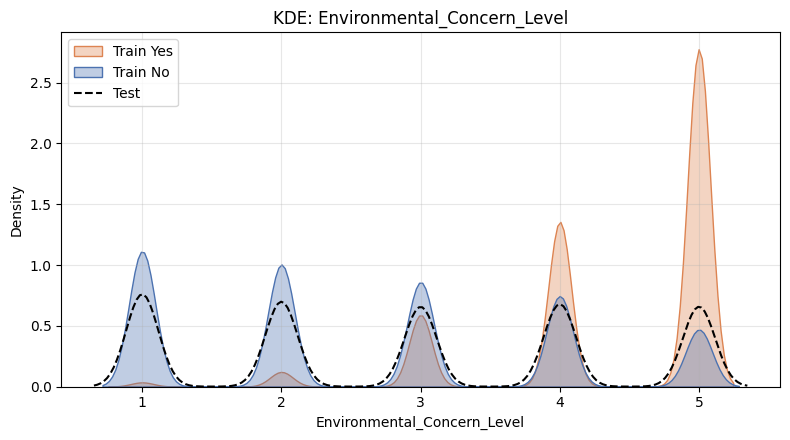

In [40]:
for c in num_cols:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.kdeplot(train.loc[train[TARGET] == 1, c], label="Train Yes",
                ax=ax, fill=True, alpha=0.35, color="#DD8452")
    sns.kdeplot(train.loc[train[TARGET] == 0, c], label="Train No",
                ax=ax, fill=True, alpha=0.35, color="#4C72B0")
    sns.kdeplot(test[c], label="Test", ax=ax, color="black", ls="--")
    ax.set_title(f"KDE: {c}")
    ax.set_xlabel(c)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/kde_{c}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# UNIFIED SIGNAL TABLE

                    feature type  mutual_info  pearson  rank_biserial  cramers_v
Environmental_Concern_Level  num       0.1476   0.4641        -0.6870        NaN
          Subsidy_Available  cat       0.0808      NaN            NaN     0.3424
          Annual_Income_USD  num       0.0539   0.2257        -0.3407        NaN
       Number_of_Cars_Owned  num       0.0422   0.0039        -0.0079        NaN
        Range_Anxiety_Level  cat       0.0090      NaN            NaN     0.1159
Charging_Stations_Near_Home  num       0.0081  -0.0164         0.0318        NaN
           Daily_Commute_km  num       0.0057  -0.0459         0.0675        NaN
Charging_Stations_Near_Work  num       0.0053  -0.0122         0.0212        NaN
                        Age  num       0.0039  -0.0074         0.0111        NaN
     Home_Charging_Possible  cat       0.0037      NaN            NaN     0.0836
                  City_Type  cat       0.0006      NaN            NaN     0.0333
           Current_Car_Type 

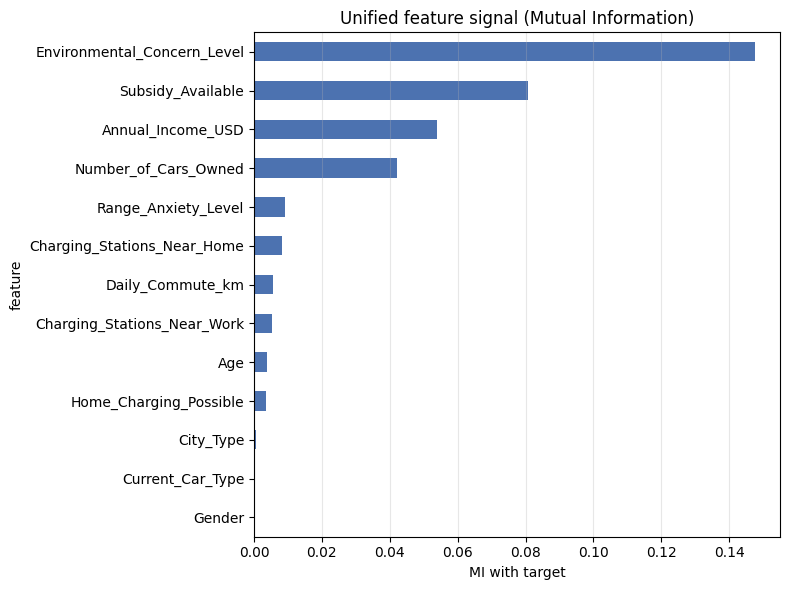

In [41]:
pearson = train[num_cols + [TARGET]].corr()[TARGET].drop(TARGET)

rows = []
for c in num_cols + cat_cols:
    if c in num_cols:
        pear = pearson.get(c, np.nan)
        mw = mw_df.set_index("feature").loc[c, "rank_biserial"] if c in mw_df["feature"].values else np.nan
        cram = np.nan
    else:
        pear = np.nan
        mw = np.nan
        cram = chi_df.set_index("feature").loc[c, "cramers_v"] if c in chi_df["feature"].values else np.nan
    rows.append({
        "feature": c,
        "type": "num" if c in num_cols else "cat",
        "mutual_info": mi_series.get(c, np.nan),
        "pearson": pear,
        "rank_biserial": mw,
        "cramers_v": cram,
    })

signal = pd.DataFrame(rows).sort_values("mutual_info", ascending=False)
print(signal.round(4).to_string(index=False))
signal.to_csv(f"{PLOT_PATH}/signal_summary.csv", index=False)

# Bar chart of MI for a visual
fig, ax = plt.subplots(figsize=(8, 6))
signal.set_index("feature")["mutual_info"].plot.barh(ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_title("Unified feature signal (Mutual Information)")
ax.set_xlabel("MI with target")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/signal_summary.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()